# StructML Final Project - Relational Deep Learning Ablation Study

This notebook contains the **code and all results** (tables, figures) of the ablation study: four experimental aspects on two rel-bench entity-classification tasks (rel-stack / user-engagement, rel-trial / study-outcome), plus a dry foundation-models question.

**The full documentation - experimental designs, fair-comparison protocol, discussions, summary, and AI-usage statement - is in [`report.md`](report.md).** Each section below keeps only a short note on what is implemented.

Shared protocol in one line: same graphs (column-wise features, GloVe text), temporal `NeighborLoader` mini-batching, same hidden size / depth / head / training budget inside every comparison; metrics = ROC AUC, AUPRC, precision, recall on the **validation** split (rel-bench hides test labels), threshold = best F1 on val; **3 seeds** (42/43/44, mean +/- std) for every configuration on both datasets; converged budgets: up to 30 epochs (early stopping on validation AUROC, patience 6; Aspect 4 additionally caps 1000 steps/epoch). Per-epoch loss curves are logged for every run (`artifacts/loss_curves_A*.csv`).

## Aspect 1 - Message Directionality (report section 3)

Three directionality modes on two backbones (GraphSAGE, GAT), realized through relbench's forward `f2p_*` / reverse `rev_f2p_*` edge types:
- **MPNN-D**: forward edges only. **MPNN-U**: both directions, one shared transform (reverse convs are literally the same modules as their forward convs). **Dir-GNN**: both directions, separate weights (2x GNN params).

Identical encoder, hidden size, depth, fan-out, head and training for all variants; parameter counts confirm the isolation (MPNN-D = MPNN-U, Dir-GNN = 2x). Memory note: hold **one dataset at a time** (rel-trial's graph build peaks near 13 GB RAM).

In [1]:
# ---------- Aspect 1: setup ----------
import os, sys, ctypes, time, gc, random
try:
    ctypes.CDLL(os.path.join(sys.prefix, "lib", "libnvrtc.so.13"), mode=ctypes.RTLD_GLOBAL)
except OSError:
    pass
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from torch_geometric.nn import SAGEConv, HeteroConv
from torch_geometric.loader import NeighborLoader
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.graph import make_pkey_fkey_graph, get_node_train_table_input
from relbench.modeling.utils import get_stype_proposal
from relbench.modeling.nn import HeteroEncoder
from torch_frame.config.text_embedder import TextEmbedderConfig
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACTS = os.environ.get("STRUCTML_ARTIFACTS", "/home/abed/structed_ML/hw3/artifacts")
os.makedirs(os.path.join(ARTIFACTS, "graph_cache"), exist_ok=True)
print("device:", device, "| pyg-lib:", __import__("torch_geometric").typing.WITH_PYG_LIB)

TASKS = [("rel-stack", "user-engagement"), ("rel-trial", "study-outcome")]
MODES = ["MPNN-D", "MPNN-U", "Dir-GNN"]

# Hyper-parameters shared by all variants (tune here).
HIDDEN = 128
NUM_LAYERS = 2
NUM_NEIGHBORS = 128
BATCH_SIZE = 512
LR = 1e-3
EPOCHS = 30
PATIENCE = 6
MAX_STEPS_PER_EPOCH = 500   # cap train batches/epoch (rel-stack train is 1.36M rows)
SEED = 42

def seeds_for(ds):
    # Converged protocol: 3 seeds for every configuration on both datasets.
    return [42, 43, 44]

def lc_logger(lc_file):
    # Per-epoch loss-curve logging for the official run cells. Each run first purges
    # its own stale rows (a crashed run restarts from scratch), then appends one row
    # per epoch; the CSV is rewritten after every epoch (crash-safe).
    rows = pd.read_csv(lc_file).to_dict("records") if os.path.exists(lc_file) else []
    def start(dataset, variant, seed):
        key = (dataset, variant, int(seed))
        rows[:] = [r for r in rows if (r["dataset"], r["variant"], int(r["seed"])) != key]
        def cb(d):
            d.update(dataset=dataset, variant=variant, seed=seed)
            rows.append(d)
            pd.DataFrame(rows).to_csv(lc_file, index=False)
        return cb
    return start
TEXT_DIM = 128              # GloVe (300d) randomly projected to this dim to bound RAM

# Column-wise text features: relbench-standard GloVe (averaged word vectors), then a fixed
# random projection to TEXT_DIM so the materialized graph fits in ~14 GB RAM.
class GloveTextEmbedder:
    def __init__(self, out_dim=128, device=None, seed=0):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(
            "sentence-transformers/average_word_embeddings_glove.6B.300d", device=device)
        g = torch.Generator().manual_seed(seed)
        self.proj = torch.randn(300, out_dim, generator=g) / (out_dim ** 0.5)
        self.out_dim = out_dim
    @torch.no_grad()
    def __call__(self, sentences):
        sents = [s if isinstance(s, str) and s.strip() else "unknown" for s in sentences]
        emb = self.model.encode(sents, convert_to_numpy=True,
                                batch_size=512, show_progress_bar=False)
        return torch.nan_to_num(torch.from_numpy(emb).float() @ self.proj)

class ZeroTextEmbedder:  # no-op placeholder, used only on a graph-cache hit
    def __init__(self, dim): self.dim = dim
    def __call__(self, sentences): return torch.zeros(len(sentences), self.dim)

_TEXT_EMBEDDER = None
def get_text_embedder():
    global _TEXT_EMBEDDER
    if _TEXT_EMBEDDER is None:
        _TEXT_EMBEDDER = GloveTextEmbedder(TEXT_DIM, device=device)
    return _TEXT_EMBEDDER

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def build_or_load_graph(name):
    # Loads the cached GloVe graph if present, else builds and caches it (one-time, heavy).
    ds = get_dataset(name, download=True)
    db = ds.get_db()
    cache = os.path.join(ARTIFACTS, "graph_cache", f"{name}_glove")
    hit = os.path.isdir(cache) and len(os.listdir(cache)) > 0
    emb = ZeroTextEmbedder(TEXT_DIM) if hit else get_text_embedder()  # skip GloVe load on hit
    cfg = TextEmbedderConfig(text_embedder=emb, batch_size=4096)
    data, col_stats = make_pkey_fkey_graph(db, get_stype_proposal(db), cfg, cache_dir=cache)
    return data, col_stats

def make_loader(data, task, split, shuffle):
    ti = get_node_train_table_input(table=task.get_table(split), task=task)
    return NeighborLoader(
        data, num_neighbors=[NUM_NEIGHBORS] * NUM_LAYERS, time_attr="time",
        input_nodes=ti.nodes, input_time=ti.time, transform=ti.transform,
        batch_size=BATCH_SIZE, temporal_strategy="uniform", shuffle=shuffle, num_workers=0)

def pos_weight_of(task):
    y = task.get_table("train").df[task.target_col].values.astype(float)
    pos = y.sum(); neg = len(y) - pos
    return torch.tensor([neg / max(pos, 1.0)], dtype=torch.float, device=device)

# ---- shared plotting helper (used by every aspect's figure cell) ----
import matplotlib.pyplot as plt

def plot_aspect_metrics(df, variant_col, title,
                        metrics=("AUROC", "AUPRC", "precision", "recall"), save_path=None):
    datasets = list(dict.fromkeys(df["dataset"]))
    variants = list(dict.fromkeys(df[variant_col]))
    x = np.arange(len(datasets)); w = 0.8 / max(len(variants), 1)
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4))
    for ax, metric in zip(axes, metrics):
        for i, v in enumerate(variants):
            grp = [df[(df["dataset"] == d) & (df[variant_col] == v)][metric] for d in datasets]
            vals = [g.mean() for g in grp]
            errs = [(g.std() if len(g) > 1 else 0.0) for g in grp]   # std over seeds where repeated
            ax.bar(x + i * w - 0.4 + w / 2, vals, w, yerr=errs, capsize=2, label=str(v))
        ax.set_xticks(x); ax.set_xticklabels(datasets)
        ax.set_title(metric); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("validation score")
    axes[-1].legend(title=variant_col, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(title); fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
    return fig


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | pyg-lib: True


In [2]:
# ---------- Aspect 1: directionality-configurable GNN (GraphSAGE or GAT backbone) ----------
import os, sys, ctypes  # preload libnvrtc BEFORE importing torch_geometric so pyg-lib loads
try:
    ctypes.CDLL(os.path.join(sys.prefix, "lib", "libnvrtc.so.13"), mode=ctypes.RTLD_GLOBAL)
except OSError:
    pass
from torch_geometric.nn import GATConv

GAT_HEADS = 4  # attention heads for the GAT backbone (head-averaged, output dim = HIDDEN)

def make_hetero_conv(edge_types, ch, mode, backbone):
    def new_conv():
        if backbone == "SAGE":
            return SAGEConv((ch, ch), ch, aggr="mean")
        return GATConv((ch, ch), ch, heads=GAT_HEADS, concat=False, add_self_loops=False)
    fwd = [e for e in edge_types if not e[1].startswith("rev_")]
    rev = [e for e in edge_types if e[1].startswith("rev_")]
    convs = {}
    if mode == "MPNN-D":                      # forward edges only
        for e in fwd:
            convs[e] = new_conv()
    elif mode == "MPNN-U":                     # both directions, shared weights
        rel2conv = {}
        for e in fwd:
            c = new_conv(); rel2conv[e[1]] = c; convs[e] = c
        for e in rev:
            convs[e] = rel2conv[e[1][len("rev_"):]]   # tie reverse to its forward conv
    elif mode == "Dir-GNN":                    # both directions, separate weights
        for e in fwd + rev:
            convs[e] = new_conv()
    else:
        raise ValueError(mode)
    return HeteroConv(convs, aggr="sum")

class DirectionalModel(nn.Module):
    def __init__(self, data, col_stats, channels, num_layers, mode, backbone="SAGE"):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels, {nt: data[nt].tf.col_names_dict for nt in data.node_types}, col_stats)
        self.convs = nn.ModuleList(
            [make_hetero_conv(data.edge_types, channels, mode, backbone) for _ in range(num_layers)])
        self.head = nn.Sequential(nn.Linear(channels, channels), nn.ReLU(), nn.Linear(channels, 1))

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        for conv in self.convs:
            o = conv(x, batch.edge_index_dict)
            x = {nt: (torch.relu(o[nt]) if nt in o else x[nt]) for nt in x}
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(x[entity_table][:n]).squeeze(-1)


In [3]:
# ---------- Aspect 1: train + 4-metric evaluation (reported on validation) ----------
@torch.no_grad()
def evaluate(model, loader, entity_table, loss_fn=None):
    # loss_fn is optional and only used by the loss-curve diagnostic below; passing
    # nothing reproduces the exact original behavior used by every official result.
    model.eval(); ys, ps, losses = [], [], []
    for batch in loader:
        batch = batch.to(device)
        logit = model(batch, entity_table)
        if loss_fn is not None:
            losses.append(loss_fn(logit, batch[entity_table].y.float()).item())
        ps.append(torch.sigmoid(logit).cpu()); ys.append(batch[entity_table].y.cpu())
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    i = int(np.argmax(f1))
    out = dict(AUROC=roc_auc_score(y, p), AUPRC=average_precision_score(y, p),
                precision=float(prec[i]), recall=float(rec[i]),
                f1=float(f1[i]), threshold=float(thr[i]))
    if loss_fn is not None:
        out["loss"] = float(np.mean(losses))
    return out

def train_model(model, train_loader, val_loader, entity_table, pos_weight, on_epoch=None,
                epochs=None, patience=None, lr=None):
    # on_epoch(dict) is an optional callback used only by the loss-curve diagnostic
    # below; it fires once per epoch with train/val loss + val AUROC. epochs/patience/lr
    # let confirmatory follow-up runs use a bigger budget or a different learning rate
    # without touching the official protocol. Official result cells call this with none
    # of these, so their behavior is completely unchanged.
    epochs = EPOCHS if epochs is None else epochs
    patience = PATIENCE if patience is None else patience
    lr = LR if lr is None else lr
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_auroc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        train_losses = []
        for i, batch in enumerate(train_loader):
            if MAX_STEPS_PER_EPOCH and i >= MAX_STEPS_PER_EPOCH:
                break
            batch = batch.to(device)
            opt.zero_grad()
            logit = model(batch, entity_table)
            loss = loss_fn(logit, batch[entity_table].y.float())
            loss.backward(); opt.step()
            if on_epoch is not None:
                train_losses.append(loss.item())
        m = evaluate(model, val_loader, entity_table, loss_fn=loss_fn if on_epoch is not None else None)
        if on_epoch is not None:
            on_epoch(dict(epoch=ep + 1, train_loss=float(np.mean(train_losses)),
                          val_loss=m["loss"], val_AUROC=m["AUROC"]))
        if m["AUROC"] > best_auroc:
            best_auroc = m["AUROC"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [4]:
# ---------- Aspect 1: run all variants (SAGE + GAT; 3 seeds on rel-trial; resumable) ----------
BACKBONES = ["SAGE", "GAT"]
csv_path = os.path.join(ARTIFACTS, "aspect1_results.csv")
lc_start = lc_logger(os.path.join(ARTIFACTS, "loss_curves_A1.csv"))
if os.path.exists(csv_path):
    _prev = pd.read_csv(csv_path)
    if "backbone" not in _prev.columns:
        _prev["backbone"] = "SAGE"      # migrate pre-GAT results
    if "seed" not in _prev.columns:
        _prev["seed"] = SEED            # migrate pre-multi-seed results
    results = _prev.to_dict("records")
else:
    results = []
done = {(r["dataset"], r["backbone"], r["mode"], int(r["seed"])) for r in results}

for dataset_name, task_name in TASKS:
    todo = [(bb, mode, sd) for bb in BACKBONES for mode in MODES
            for sd in seeds_for(dataset_name) if (dataset_name, bb, mode, sd) not in done]
    if not todo:
        print(f"{dataset_name}: all variants cached, skipping"); continue
    print(f"\n##### {dataset_name} / {task_name} ##### ({len(todo)} runs)")
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True)
    et = task.entity_table
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    for backbone, mode, sd in todo:
        set_seed(sd)
        model = DirectionalModel(data, col_stats, HIDDEN, NUM_LAYERS, mode, backbone).to(device)
        nparams = sum(p.numel() for p in model.parameters())
        t0 = time.time()
        model = train_model(model, train_loader, val_loader, et, pw,
                            on_epoch=lc_start(dataset_name, f"{backbone}-{mode}", sd))
        m = evaluate(model, val_loader, et)
        m.update(dataset=dataset_name, backbone=backbone, mode=mode, seed=sd, params=nparams,
                 train_s=time.time() - t0)
        results.append(m); done.add((dataset_name, backbone, mode, sd))
        pd.DataFrame(results).to_csv(csv_path, index=False)   # save after each run (crash-safe)
        print(f"  {backbone}-{mode:8s} seed={sd} AUROC={m['AUROC']:.4f} AUPRC={m['AUPRC']:.4f} "
              f"P={m['precision']:.3f} R={m['recall']:.3f} params={nparams/1e6:.2f}M t={m['train_s']:.0f}s")
        del model; gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)[
    ["dataset", "backbone", "mode", "seed", "AUROC", "AUPRC", "precision", "recall", "f1", "params", "train_s"]]
results_df.to_csv(csv_path, index=False)
(results_df.groupby(["dataset", "backbone", "mode"])
 .agg(AUROC=("AUROC", "mean"), AUROC_std=("AUROC", "std"), AUPRC=("AUPRC", "mean"),
      precision=("precision", "mean"), recall=("recall", "mean"), params=("params", "first"))
 .round(4))


rel-stack: all variants cached, skipping
rel-trial: all variants cached, skipping


AUROC  AUROC_std   AUPRC  precision  recall  \
dataset   backbone mode                                                    
rel-stack GAT      Dir-GNN  0.8639        NaN  0.2627     0.2915  0.3675   
                   MPNN-D   0.8677        NaN  0.2950     0.3441  0.3360   
                   MPNN-U   0.8601        NaN  0.2610     0.2826  0.3737   
          SAGE     Dir-GNN  0.8642        NaN  0.2675     0.2944  0.3422   
                   MPNN-D   0.8682        NaN  0.2876     0.3431  0.3194   
                   MPNN-U   0.8675        NaN  0.2694     0.3007  0.3326   
rel-trial GAT      Dir-GNN  0.6634     0.0046  0.7305     0.6153  0.9447   
                   MPNN-D   0.6301     0.0210  0.6963     0.5951  0.9846   
                   MPNN-U   0.6614     0.0072  0.7323     0.6062  0.9691   
          SAGE     Dir-GNN  0.6832     0.0029  0.7507     0.6311  0.9162   
                   MPNN-D   0.6750     0.0043  0.7367     0.6066  0.9709   
                   MPNN-U   0.6854     0.0028  0.7540     0.6218  0.9317   

                              params  
dataset   backbone mode               
rel-stack GAT      Dir-GNN   8128129  
                   MPNN-D    5219201  
                   MPNN-U    5219201  
          SAGE     Dir-GNN   3757697  
                   MPNN-D    3033985  
                   MPNN-U    3033985  
rel-trial GAT      Dir-GNN  14215041  
                   MPNN-D   10248321  
                   MPNN-U   10248321  
          SAGE     Dir-GNN   8255361  
                   MPNN-D    7268481  
                   MPNN-U    7268481

### Aspect 1 - Key results

Validation AUROC (rel-stack: single seed; rel-trial: mean +/- std over 3 seeds):

| dataset | backbone | MPNN-D | MPNN-U | Dir-GNN |
|---|---|---|---|---|
| rel-stack | SAGE | **0.868** | 0.867 | 0.864 |
| rel-stack | GAT  | **0.868** | 0.860 | 0.864 |
| rel-trial | SAGE | 0.675 +/- 0.004 | **0.685 +/- 0.003** | 0.683 +/- 0.003 |
| rel-trial | GAT  | 0.630 +/- 0.021 | 0.661 +/- 0.007 | **0.663 +/- 0.005** |

- On rel-stack directionality barely matters (spread ~0.008, both backbones).
- On rel-trial it is **architecture-dependent**: GAT is clearly hurt without reverse edges (0.630, and the largest seed variance - unstable as well as weaker); SAGE barely moves. Mean aggregation masks the effect that attention exposes.
- MPNN-U is the safe default. Dir-GNN never meaningfully wins: on GAT/rel-trial it only ties MPNN-U within noise despite ~1.4x the parameters, so the planned param-matched control is unnecessary. (The earlier single-seed run had suggested a Dir-GNN win there, 0.669 vs 0.654; seed-averaging dissolved it - a concrete example of single-seed noise.)

Full discussion: report.md section 3.

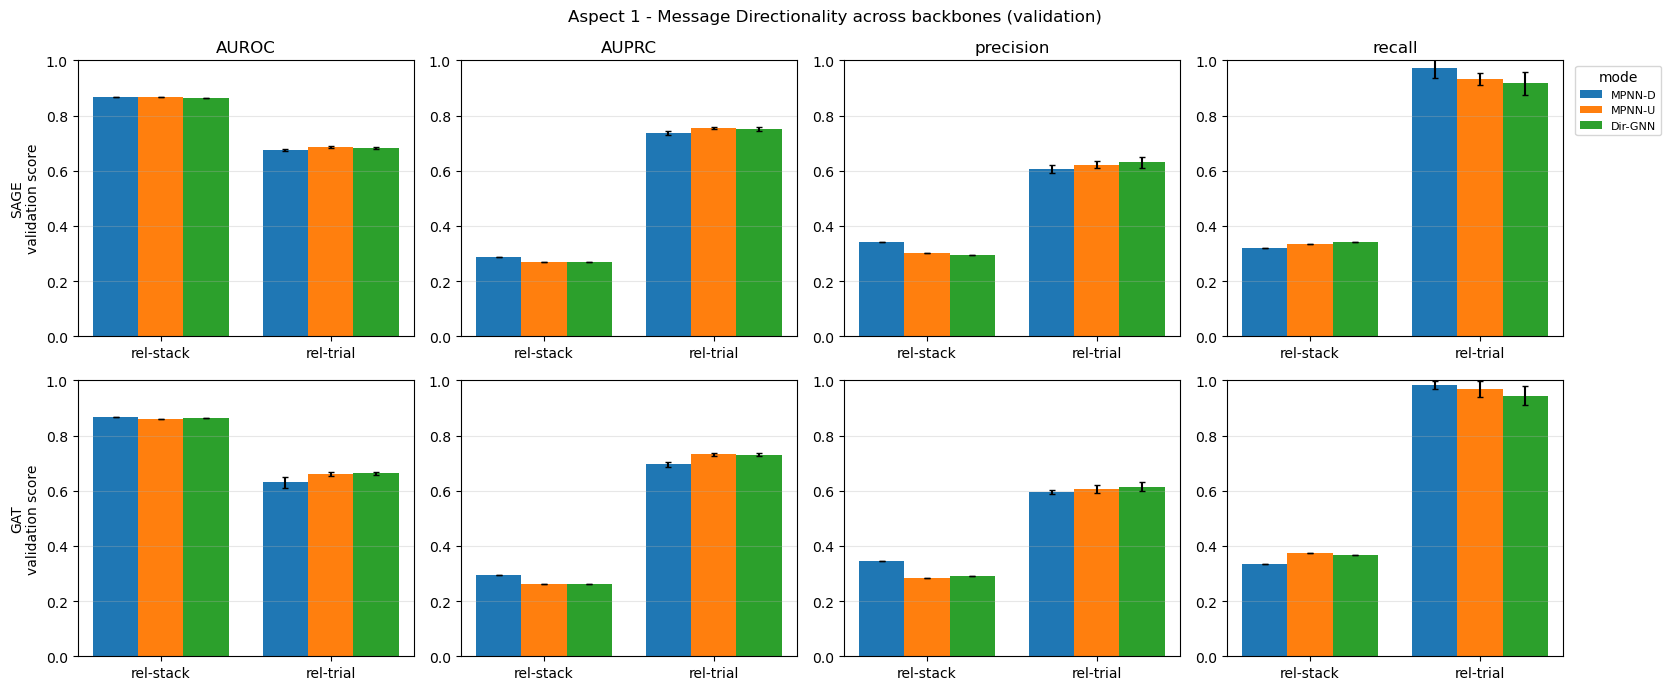

In [5]:
# ---------- Aspect 1 figure: directionality across backbones (SAGE row vs GAT row) ----------
a1 = pd.read_csv(os.path.join(ARTIFACTS, "aspect1_results.csv"))
_metrics = ["AUROC", "AUPRC", "precision", "recall"]
_backbones = ["SAGE", "GAT"]; _modes = ["MPNN-D", "MPNN-U", "Dir-GNN"]
_datasets = list(dict.fromkeys(a1["dataset"]))
fig, axes = plt.subplots(len(_backbones), len(_metrics), figsize=(4.2 * len(_metrics), 7))
x = np.arange(len(_datasets)); w = 0.8 / len(_modes)
for r, bb in enumerate(_backbones):
    for c, met in enumerate(_metrics):
        ax = axes[r][c]
        for i, mode in enumerate(_modes):
            grp = [a1[(a1.dataset == d) & (a1.backbone == bb) & (a1["mode"] == mode)][met]
                   for d in _datasets]
            vals = [g.mean() for g in grp]
            errs = [(g.std() if len(g) > 1 else 0.0) for g in grp]
            ax.bar(x + i * w - 0.4 + w / 2, vals, w, yerr=errs, capsize=2, label=mode)
        ax.set_xticks(x); ax.set_xticklabels(_datasets); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
        if r == 0:
            ax.set_title(met)
        if c == 0:
            ax.set_ylabel(f"{bb}\nvalidation score")
axes[0][-1].legend(title="mode", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Aspect 1 - Message Directionality across backbones (validation)")
fig.tight_layout()
fig.savefig(os.path.join(ARTIFACTS, "aspect1_metrics.png"), dpi=130, bbox_inches="tight")
plt.show()


## Aspect 2 - Heterogeneity (report section 4)

Homogeneous vs heterogeneous message passing for two families: **SAGE-hetero** (`HeteroConv`, per-edge-type convs), **SAGE-homo** (post-encoder `collapse()` to one node set + one merged edge set, single shared conv), **HGT-hetero** (native types), **HGT-homo** (explicit single-type `HeteroData`, as the spec requires).

All four share the same `HeteroEncoder` (course staff confirmed this is allowed for the homogeneous setting, provided the typed graph is converted to a homogeneous view - `collapse()` is exactly that conversion), the same head and training; only the message-passing block differs. Reuses the Aspect 1 setup + train/eval cells; run those first.

In [6]:
# ---------- Aspect 2: homogeneous vs heterogeneous models ----------
import torch_geometric
from torch_geometric.nn import HGTConv
from torch_geometric.data import HeteroData

# HGTConv runs its per-type projections through pyg_lib grouped GEMM, which crashes
# ("GroupedGEMM run failed" / CUDA illegal address) when a node type has 0 nodes in a
# mini-batch - common in rel-trial's 15-type graph. Force the loop-based path, which
# tolerates empty groups. Global setting; also needed by the HGT model in Aspect 3.
torch_geometric.backend.use_segment_matmul = False

HEADS = 4  # HGT attention heads (must divide HIDDEN)

def collapse(x_dict, edge_index_dict, node_types):
    # Merge a post-encoder hetero graph into one node set + one edge set.
    offsets = {}; xs = []; off = 0
    for nt in node_types:
        offsets[nt] = off; xs.append(x_dict[nt]); off += x_dict[nt].size(0)
    x_all = torch.cat(xs, dim=0)
    eis = []
    for (s, rel, d), ei in edge_index_dict.items():
        if ei.numel() == 0:
            continue
        eis.append(torch.stack([ei[0] + offsets[s], ei[1] + offsets[d]], dim=0))
    ei_all = torch.cat(eis, dim=1) if eis else torch.zeros(2, 0, dtype=torch.long, device=x_all.device)
    return x_all, ei_all, offsets

class Aspect2Model(nn.Module):
    def __init__(self, data, col_stats, ch, L, family, hetero, heads=HEADS):
        super().__init__()
        self.encoder = HeteroEncoder(
            ch, {nt: data[nt].tf.col_names_dict for nt in data.node_types}, col_stats)
        self.node_types = list(data.node_types); self.family = family; self.hetero = hetero
        if hetero and family == "SAGE":
            self.convs = nn.ModuleList([HeteroConv(
                {et: SAGEConv((ch, ch), ch, aggr="mean") for et in data.edge_types}, aggr="sum")
                for _ in range(L)])
        elif hetero and family == "HGT":
            self.convs = nn.ModuleList([HGTConv(ch, ch, data.metadata(), heads=heads) for _ in range(L)])
        elif (not hetero) and family == "SAGE":
            self.convs = nn.ModuleList([SAGEConv(ch, ch, aggr="mean") for _ in range(L)])
        else:  # HGT-homo: single node type, single edge type
            self.meta = (["node"], [("node", "to", "node")])
            self.convs = nn.ModuleList([HGTConv(ch, ch, self.meta, heads=heads) for _ in range(L)])
        self.head = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, 1))

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        if self.hetero:
            for conv in self.convs:
                o = conv(x, batch.edge_index_dict)
                x = {nt: (torch.relu(o[nt]) if nt in o else x[nt]) for nt in x}
            ent = x[entity_table]
        else:
            x_all, ei_all, offs = collapse(x, batch.edge_index_dict, self.node_types)
            for conv in self.convs:
                if self.family == "SAGE":
                    x_all = torch.relu(conv(x_all, ei_all))
                else:  # HGT-homo: build an explicit single-type HeteroData (all nodes one type, all edges one type)
                    hom = HeteroData()
                    hom["node"].x = x_all
                    hom["node", "to", "node"].edge_index = ei_all
                    x_all = torch.relu(conv(hom.x_dict, hom.edge_index_dict)["node"])
            o0 = offs[entity_table]; ent = x_all[o0:o0 + x[entity_table].size(0)]
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(ent[:n]).squeeze(-1)


In [7]:
# ---------- Aspect 2: run all variants (3 seeds on rel-trial; resumable + crash-safe) ----------
VARIANTS = [("SAGE", False), ("SAGE", True), ("HGT", False), ("HGT", True)]
csv_path = os.path.join(ARTIFACTS, "aspect2_results.csv")
lc_start = lc_logger(os.path.join(ARTIFACTS, "loss_curves_A2.csv"))
if os.path.exists(csv_path):
    _prev = pd.read_csv(csv_path)
    if "seed" not in _prev.columns:
        _prev["seed"] = SEED            # migrate pre-multi-seed results
    results2 = _prev.to_dict("records")
else:
    results2 = []
done = {(r["dataset"], r["model"], r["setting"], int(r["seed"])) for r in results2}

for dataset_name, task_name in TASKS:
    todo = [(f, h, sd) for f, h in VARIANTS for sd in seeds_for(dataset_name)
            if (dataset_name, f, "hetero" if h else "homo", sd) not in done]
    if not todo:
        print(f"{dataset_name}: all variants cached, skipping"); continue
    print(f"\n##### {dataset_name} / {task_name} ##### ({len(todo)} runs)")
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True)
    et = task.entity_table
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    for family, hetero, sd in todo:
        setting = "hetero" if hetero else "homo"
        set_seed(sd)
        model = Aspect2Model(data, col_stats, HIDDEN, NUM_LAYERS, family, hetero, heads=HEADS).to(device)
        nparams = sum(p.numel() for p in model.parameters())
        t0 = time.time()
        model = train_model(model, train_loader, val_loader, et, pw,
                            on_epoch=lc_start(dataset_name, f"{family}-{setting}", sd))
        m = evaluate(model, val_loader, et)
        m.update(dataset=dataset_name, model=family, setting=setting, seed=sd, params=nparams,
                 train_s=time.time() - t0)
        results2.append(m); done.add((dataset_name, family, setting, sd))
        pd.DataFrame(results2).to_csv(csv_path, index=False)
        print(f"  {family}-{setting:6s} seed={sd} AUROC={m['AUROC']:.4f} AUPRC={m['AUPRC']:.4f} "
              f"P={m['precision']:.3f} R={m['recall']:.3f} params={nparams/1e6:.2f}M t={m['train_s']:.0f}s")
        del model; gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

results2_df = pd.DataFrame(results2)[
    ["dataset", "model", "setting", "seed", "AUROC", "AUPRC", "precision", "recall", "f1", "params", "train_s"]]
results2_df.to_csv(csv_path, index=False)
(results2_df.groupby(["dataset", "model", "setting"])
 .agg(AUROC=("AUROC", "mean"), AUROC_std=("AUROC", "std"), AUPRC=("AUPRC", "mean"),
      precision=("precision", "mean"), recall=("recall", "mean"), params=("params", "first"))
 .round(4))


rel-stack: all variants cached, skipping
rel-trial: all variants cached, skipping


AUROC  AUROC_std   AUPRC  precision  recall  \
dataset   model setting                                                   
rel-stack HGT   hetero     0.8610        NaN  0.2492     0.2752  0.3521   
                homo       0.8652        NaN  0.2767     0.3044  0.3530   
          SAGE  hetero     0.8598        NaN  0.2489     0.2797  0.3322   
                homo       0.8738        NaN  0.2985     0.3372  0.3289   
rel-trial HGT   hetero     0.6666     0.0025  0.7246     0.6052  0.9691   
                homo       0.6688     0.0053  0.7227     0.6089  0.9626   
          SAGE  hetero     0.6922     0.0039  0.7592     0.6083  0.9655   
                homo       0.6688     0.0027  0.7307     0.6125  0.9542   
                homo-wide  0.6661     0.0023  0.7218     0.6124  0.9548   

                            params  
dataset   model setting             
rel-stack HGT   hetero     3595583  
                homo       2458763  
          SAGE  hetero     3757697  
                homo       2376065  
rel-trial HGT   hetero     8754831  
                homo       6430091  
          SAGE  hetero     8255361  
                homo       6347393  
                homo-wide  6702497

In [8]:
# ---------- Aspect 2 control: parameter-matched homogeneous SAGE on rel-trial ----------
# SAGE-hetero wins on rel-trial (0.692 vs 0.669) but also has more parameters (8.26M vs
# 6.35M). This control widens the homogeneous model until its TOTAL parameter count
# matches the heterogeneous one, separating "type-awareness helps" from "capacity helps".
# Needs: setup (aspect1-1), train/eval (aspect1-3), Aspect2Model (aspect2-1). 3 seeds, ~5 min.
CTRL_DATASET, CTRL_TASK = "rel-trial", "study-outcome"
csv_path = os.path.join(ARTIFACTS, "aspect2_results.csv")
lc_start = lc_logger(os.path.join(ARTIFACTS, "loss_curves_A2.csv"))
results2 = pd.read_csv(csv_path).to_dict("records")
done = {(r["dataset"], r["model"], r["setting"], int(r.get("seed", SEED))) for r in results2}
todo = [sd for sd in seeds_for(CTRL_DATASET) if (CTRL_DATASET, "SAGE", "homo-wide", sd) not in done]
if not todo:
    print("control cached, skipping")
else:
    data, col_stats = build_or_load_graph(CTRL_DATASET)
    task = get_task(CTRL_DATASET, CTRL_TASK, download=True); et = task.entity_table
    target = [r["params"] for r in results2 if r["dataset"] == CTRL_DATASET
              and r["model"] == "SAGE" and r["setting"] == "hetero"][0]
    best = None
    for ch in range(136, 225, 8):   # pick the width whose total params best match hetero's
        n = sum(p.numel() for p in Aspect2Model(data, col_stats, ch, NUM_LAYERS, "SAGE", False).parameters())
        if best is None or abs(n - target) < abs(best[1] - target):
            best = (ch, n)
    ch_w, n_w = best
    print(f"hetero target={target/1e6:.2f}M -> homo-wide hidden={ch_w} ({n_w/1e6:.2f}M)")
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    for sd in todo:
        set_seed(sd)
        model = Aspect2Model(data, col_stats, ch_w, NUM_LAYERS, "SAGE", False).to(device)
        nparams = sum(p.numel() for p in model.parameters())
        t0 = time.time()
        model = train_model(model, train_loader, val_loader, et, pw,
                            on_epoch=lc_start(CTRL_DATASET, "SAGE-homo-wide", sd))
        m = evaluate(model, val_loader, et)
        m.update(dataset=CTRL_DATASET, model="SAGE", setting="homo-wide", seed=sd,
                 params=nparams, train_s=time.time() - t0)
        results2.append(m)
        pd.DataFrame(results2).to_csv(csv_path, index=False)
        print(f"  homo-wide seed={sd} AUROC={m['AUROC']:.4f} AUPRC={m['AUPRC']:.4f} "
              f"P={m['precision']:.3f} R={m['recall']:.3f} params={nparams/1e6:.2f}M t={m['train_s']:.0f}s")
        del model; gc.collect()
        if device.type == "cuda": torch.cuda.empty_cache()
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()
    a = pd.DataFrame(results2)
    a = a[(a.dataset == CTRL_DATASET) & (a.model == "SAGE")]
    print(a.groupby("setting")["AUROC"].agg(["mean", "std"]).round(4))


control cached, skipping


### Aspect 2 - Key results

Validation AUROC (rel-stack: single seed; rel-trial: mean +/- std over 3 seeds):

| dataset | model | homo | hetero | homo params | hetero params |
|---|---|---|---|---|---|
| rel-stack | SAGE | **0.874** | 0.860 | 2.38M | 3.76M |
| rel-stack | HGT  | **0.865** | 0.861 | 2.46M | 3.60M |
| rel-trial | SAGE | 0.669 +/- 0.003 | **0.692 +/- 0.004** | 6.35M | 8.26M |
| rel-trial | HGT  | 0.669 +/- 0.005 | 0.667 +/- 0.003 | 6.43M | 8.75M |

- Opposite of the expectation: heterogeneity helps in only 1 of 4 model/dataset combinations (SAGE on rel-trial, a robust +0.023 across seeds) and loses on rel-stack **despite more parameters** (shared weights pool data and regularize; per-type weights fragment over 22-30 edge types).
- HGT: homo and hetero are statistically tied on rel-trial; homo wins on rel-stack. The biggest model (HGT-hetero, 8.75M) is never the best.

Full discussion: report.md section 4.

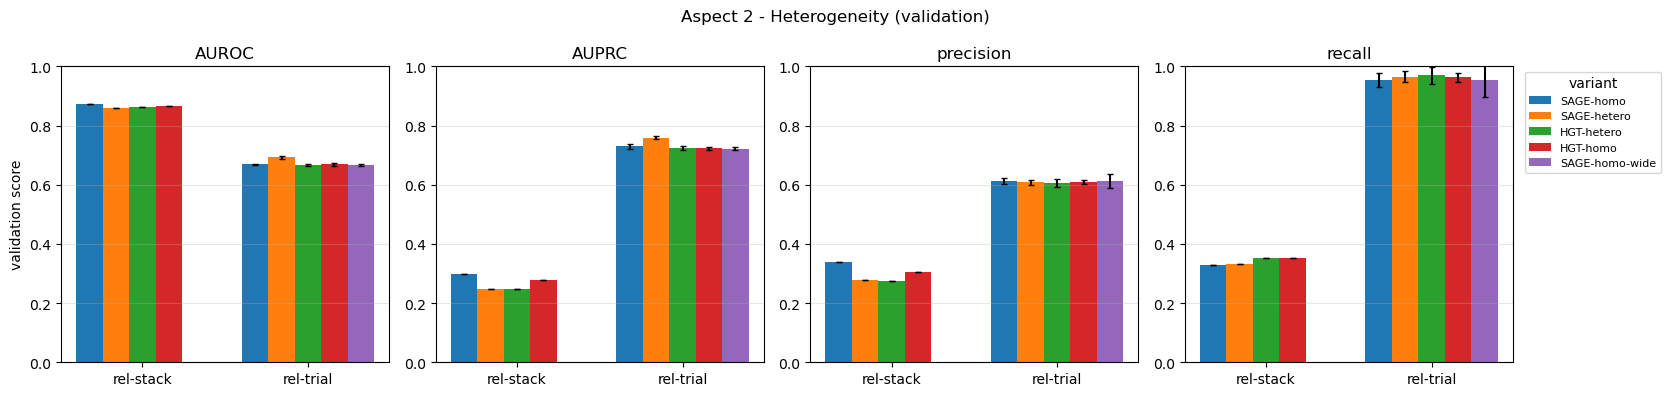

In [9]:
# ---------- Aspect 2 figure (reuses plot_aspect_metrics from the Aspect 1 figure cell) ----------
a2 = pd.read_csv(os.path.join(ARTIFACTS, "aspect2_results.csv"))
a2["variant"] = a2["model"] + "-" + a2["setting"]
plot_aspect_metrics(a2, "variant", "Aspect 2 - Heterogeneity (validation)",
                    save_path=os.path.join(ARTIFACTS, "aspect2_metrics.png"))
plt.show()


## Aspect 3 - Node Features: id / column-wise / LLM (report section 5)

Three input encoders on an identical HGT backbone + head, trained with the **same mini-batch harness as Aspects 1-2**, on one fixed cached subsample per dataset (identical for all three strategies, as the spec requires): label-stratified seed entities (6000 train + 2000 val, exact positive rates preserved, printed at build) + 2-hop time-respecting neighborhoods, with MiniLM row embeddings precomputed.

- **id**: `nn.Embedding` per node type by subgraph node id (transductive). **column**: shared `HeteroEncoder`. **llm**: frozen MiniLM (`"col=val, ..."` serialization) + per-type `Linear(384, hidden)`.
- **3 seeds per variant**, mean +/- std (single-seed proved too noisy at this sample size).

Run setup (aspect1-1) + the train/eval cell (aspect1-3) first. The subgraph build is cached; if rebuilding, one dataset per fresh process (~13 GB RAM).

In [10]:
# ---------- Aspect 3: fixed shared subsample + 3-encoder HGT model ----------
import torch_geometric
from torch_geometric.nn import HGTConv

A3_HEADS = 4
A3_SEEDS = [42, 43, 44]           # cheap runs -> 3 seeds, report mean +/- std
A3_NTRAIN, A3_NVAL = 6000, 2000   # label-stratified seed entities per split
A3_FANOUT = [6, 6]                # 2-hop time-respecting neighborhood
A3_SUBDIR = os.path.join(ARTIFACTS, "aspect3_subgraphs")
A3_LLM = "sentence-transformers/all-MiniLM-L6-v2"

def a3_build_or_load(dataset_name, task_name):
    # One fixed subsample per dataset, cached; identical for all three strategies.
    os.makedirs(A3_SUBDIR, exist_ok=True)
    path = os.path.join(A3_SUBDIR, f"{dataset_name}.pt")
    if os.path.exists(path):
        return torch.load(path, weights_only=False)
    set_seed(SEED)
    data, col_stats = build_or_load_graph(dataset_name)
    db = get_dataset(dataset_name, download=True).get_db()
    task = get_task(dataset_name, task_name, download=True)
    et = task.entity_table

    def stratified(split_name, n):
        # label-stratified: keeps the split's positive rate exactly; one shared shuffle
        t = get_node_train_table_input(table=task.get_table(split_name), task=task)
        tgt = t.target
        pos = (tgt == 1).nonzero(as_tuple=True)[0]
        neg = (tgt == 0).nonzero(as_tuple=True)[0]
        n = min(n, len(tgt))
        n_pos = min(len(pos), round(n * len(pos) / len(tgt)))
        idx = torch.cat([pos[torch.randperm(len(pos))[:n_pos]],
                         neg[torch.randperm(len(neg))[:min(len(neg), n - n_pos)]]])
        idx = idx[torch.randperm(len(idx))]        # shuffle nodes/time/target together
        return t.nodes[1][idx], t.time[idx], t.target[idx].float()

    tn, tt, ty = stratified("train", A3_NTRAIN)
    vn, vt, vy = stratified("val", A3_NVAL)
    nodes, times = torch.cat([tn, vn]), torch.cat([tt, vt])
    y = torch.cat([ty, vy])
    split = torch.cat([torch.ones(len(tn)), torch.zeros(len(vn))]).bool()
    print(f"  [{dataset_name}] train n={len(tn)} pos-rate={ty.mean():.4f} | "
          f"val n={len(vn)} pos-rate={vy.mean():.4f}", flush=True)
    loader = NeighborLoader(data, num_neighbors=A3_FANOUT, time_attr="time",
                            input_nodes=(et, nodes), input_time=times,
                            batch_size=len(nodes), shuffle=False, num_workers=0)
    sub = next(iter(loader))
    n_seed = len(nodes)
    # seeds are the first n_seed rows of the entity store; attach labels there
    ys = torch.full((int(sub[et].num_nodes),), float("nan"))
    ys[:n_seed] = y
    sub[et].y = ys
    # precompute frozen MiniLM row embeddings for every subgraph node
    from sentence_transformers import SentenceTransformer
    mini = SentenceTransformer(A3_LLM, device=str(device))
    llm_dim = mini.get_sentence_embedding_dimension()
    for nt in sub.node_types:
        gid = sub[nt].n_id.cpu().numpy()
        if len(gid) == 0:
            sub[nt].llm_emb = torch.zeros(0, llm_dim)
        else:
            df = db.table_dict[nt].df; cols = list(df.columns); rows = df.iloc[gid]
            strs = [", ".join(f"{c}={rows.iloc[i][c]}" for c in cols) for i in range(len(rows))]
            emb = mini.encode(strs, convert_to_numpy=True, batch_size=512, show_progress_bar=False)
            sub[nt].llm_emb = torch.from_numpy(np.asarray(emb).reshape(len(gid), -1)).float()
            print(f"    embedded {nt}: {len(gid)} rows", flush=True)
    # strip the outer loader's bookkeeping so the inner NeighborLoader can set its own
    for nt in sub.node_types:
        sub[nt].gid = sub[nt].n_id            # keep global ids for provenance
        for attr in ["n_id", "input_id", "batch_size", "seed_time"]:
            if hasattr(sub[nt], attr):
                del sub[nt][attr]
    for est in sub.edge_types:
        if hasattr(sub[est], "e_id"):
            del sub[est]["e_id"]
    blob = {"sub": sub, "split": split, "n_seed": n_seed, "seed_time": times,
            "col_stats": col_stats, "llm_dim": llm_dim, "entity_table": et}
    torch.save(blob, path)
    del data, db; gc.collect()
    return blob

def a3_loaders(blob):
    # temporal mini-batch loaders over the fixed subgraph (same harness as Aspects 1-2)
    sub, split, et = blob["sub"], blob["split"], blob["entity_table"]
    seed_ids, times = torch.arange(blob["n_seed"]), blob["seed_time"]
    def trim(batch):  # keep y only for seed rows so train_model()/evaluate() work as-is
        batch[et].y = batch[et].y[:batch[et].batch_size]
        return batch
    def mk(mask, shuffle):
        return NeighborLoader(sub, num_neighbors=A3_FANOUT, time_attr="time",
                              input_nodes=(et, seed_ids[mask]), input_time=times[mask],
                              transform=trim, batch_size=BATCH_SIZE, shuffle=shuffle,
                              num_workers=0)
    return mk(split, True), mk(~split, False)

def a3_loaders_split(blob, val_frac=0.2, split_seed=SEED):
    # Fine-tuning-follow-up-only fix (llm-finetuned / llm-partial / llm-partial-shared):
    # a3_loaders()'s official `split` boolean is normally used both to pick the best
    # checkpoint (early stopping) AND to compute the final reported metric - the same
    # validation labels get looked at twice, so the reported number is for whichever
    # checkpoint happened to score best on those exact labels (a form of selection
    # leakage, not a gradient leak). Here the official TRAIN pool is itself split
    # further, label-stratified, into train'/val' (val' used only for early stopping);
    # the official `val` pool is left completely untouched during training and returned
    # separately as a genuine held-out test - evaluate it exactly once, after the best
    # checkpoint is already fixed, never to make any decision. split_seed is independent
    # of the run's model seed so all 3 seeds share the identical train'/val' boundary -
    # isolates training-run variance from split variance.
    sub, split, et = blob["sub"], blob["split"], blob["entity_table"]
    seed_ids, times = torch.arange(blob["n_seed"]), blob["seed_time"]
    y = sub[et].y[:blob["n_seed"]]

    train_idx = split.nonzero(as_tuple=True)[0]
    g = torch.Generator().manual_seed(split_seed)
    pos = train_idx[y[train_idx] == 1]
    neg = train_idx[y[train_idx] == 0]
    def carve(idx):
        perm = idx[torch.randperm(len(idx), generator=g)]
        k = int(round(len(idx) * val_frac))
        return perm[k:], perm[:k]   # (train', val')
    pos_tr, pos_val = carve(pos)
    neg_tr, neg_val = carve(neg)
    tr_mask = torch.zeros(blob["n_seed"], dtype=torch.bool)
    tr_mask[torch.cat([pos_tr, neg_tr])] = True
    val_mask = torch.zeros(blob["n_seed"], dtype=torch.bool)
    val_mask[torch.cat([pos_val, neg_val])] = True
    print(f"  [split] train'={int(tr_mask.sum())} val'={int(val_mask.sum())} "
          f"(carved from official train pool n={int(split.sum())}) | "
          f"held-out test={int((~split).sum())} (official val pool, untouched)", flush=True)

    def trim(batch):
        batch[et].y = batch[et].y[:batch[et].batch_size]
        return batch
    def mk(mask, shuffle):
        return NeighborLoader(sub, num_neighbors=A3_FANOUT, time_attr="time",
                              input_nodes=(et, seed_ids[mask]), input_time=times[mask],
                              transform=trim, batch_size=BATCH_SIZE, shuffle=shuffle,
                              num_workers=0)
    return mk(tr_mask, True), mk(val_mask, False), mk(~split, False)

class A3Model(nn.Module):
    # identical HGT backbone + head; only the input encoder differs per strategy
    def __init__(self, sub, col_stats, ch, L, strategy, llm_dim, heads=A3_HEADS):
        super().__init__()
        self.strategy = strategy
        self.nts = list(sub.node_types)
        if strategy == "column":
            self.encoder = HeteroEncoder(
                ch, {nt: sub[nt].tf.col_names_dict for nt in self.nts}, col_stats)
        elif strategy == "id":
            self.emb = nn.ModuleDict(
                {nt: nn.Embedding(max(int(sub[nt].num_nodes), 1), ch) for nt in self.nts})
        else:
            self.proj = nn.ModuleDict({nt: nn.Linear(llm_dim, ch) for nt in self.nts})
        self.convs = nn.ModuleList([HGTConv(ch, ch, sub.metadata(), heads=heads) for _ in range(L)])
        self.head = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, 1))

    def forward(self, batch, entity_table):
        if self.strategy == "column":
            x = self.encoder(batch.tf_dict)
        elif self.strategy == "id":
            x = {nt: self.emb[nt](batch[nt].n_id) for nt in self.nts}
        else:
            x = {nt: self.proj[nt](batch[nt].llm_emb) for nt in self.nts}
        for conv in self.convs:
            o = conv(x, batch.edge_index_dict)
            x = {nt: (torch.relu(o[nt]) if o.get(nt) is not None else x[nt]) for nt in x}
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(x[entity_table][:n]).squeeze(-1)


In [11]:
# ---------- Aspect 3: run 3 strategies x 3 seeds (resumable) ----------
STRATEGIES = ["id", "column", "llm"]
csv_path = os.path.join(ARTIFACTS, "aspect3_results.csv")
lc_start = lc_logger(os.path.join(ARTIFACTS, "loss_curves_A3.csv"))
results3 = pd.read_csv(csv_path).to_dict("records") if os.path.exists(csv_path) else []
done = {(r["dataset"], r["strategy"], int(r["seed"])) for r in results3}

for dataset_name, task_name in TASKS:
    if all((dataset_name, s, sd) in done for s in STRATEGIES for sd in A3_SEEDS):
        print(f"{dataset_name}: all cached, skipping"); continue
    print(f"\n##### {dataset_name} / {task_name} #####")
    # HGT empty-node-type fix needed only where mini-batches can empty a type (rel-trial)
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    blob = a3_build_or_load(dataset_name, task_name)
    sub, split, et = blob["sub"], blob["split"], blob["entity_table"]
    train_loader, val_loader = a3_loaders(blob)
    ytr = sub[et].y[:blob["n_seed"]][split]
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum().item(), 1.0)], device=device)
    print(f"  subgraph nodes={sum(int(sub[nt].num_nodes) for nt in sub.node_types)}  seeds={blob['n_seed']}")
    for strat in STRATEGIES:
        for sd in A3_SEEDS:
            if (dataset_name, strat, sd) in done:
                print(f"  {strat:7s} seed={sd} cached, skip"); continue
            set_seed(sd)
            model = A3Model(sub, blob["col_stats"], HIDDEN, NUM_LAYERS, strat, blob["llm_dim"]).to(device)
            nparams = sum(p.numel() for p in model.parameters())
            t0 = time.time()
            model = train_model(model, train_loader, val_loader, et, pw,
                                on_epoch=lc_start(dataset_name, strat, sd))
            m = evaluate(model, val_loader, et)
            m.update(dataset=dataset_name, strategy=strat, seed=sd, params=nparams,
                     train_s=time.time() - t0)
            results3.append(m); done.add((dataset_name, strat, sd))
            pd.DataFrame(results3).to_csv(csv_path, index=False)
            print(f"  {strat:7s} seed={sd} AUROC={m['AUROC']:.4f} AUPRC={m['AUPRC']:.4f} "
                  f"P={m['precision']:.3f} R={m['recall']:.3f} params={nparams/1e6:.2f}M t={m['train_s']:.0f}s")
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()
    del blob, sub, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

results3_df = pd.DataFrame(results3)[
    ["dataset", "strategy", "seed", "AUROC", "AUPRC", "precision", "recall", "f1", "params", "train_s"]]
results3_df.to_csv(csv_path, index=False)
(results3_df.groupby(["dataset", "strategy"])
 .agg(AUROC_mean=("AUROC", "mean"), AUROC_std=("AUROC", "std"),
      AUPRC_mean=("AUPRC", "mean"), AUPRC_std=("AUPRC", "std"),
      precision=("precision", "mean"), recall=("recall", "mean"),
      params=("params", "first"), train_s=("train_s", "mean")).round(4))


rel-stack: all cached, skipping
rel-trial: all cached, skipping


AUROC_mean  AUROC_std  AUPRC_mean  AUPRC_std  precision  \
dataset   strategy                                                            
rel-stack column        0.8376     0.0076      0.1556     0.0142     0.1643   
          id            0.7219     0.0184      0.0579     0.0078     0.0834   
          llm           0.7766     0.0007      0.1532     0.0122     0.2048   
rel-trial column        0.6695     0.0008      0.7270     0.0047     0.6002   
          id            0.5193     0.0119      0.5988     0.0070     0.5851   
          llm           0.6373     0.0184      0.7271     0.0284     0.5903   

                    recall    params  train_s  
dataset   strategy                             
rel-stack column    0.4881   3595583  13.4168  
          id        0.5714  25553471   5.0201  
          llm       0.3155   1646911   8.4232  
rel-trial column    0.9774   8754831  20.1983  
          id        0.9988  18396815  16.9443  
          llm       0.9905   3229071  19.0326

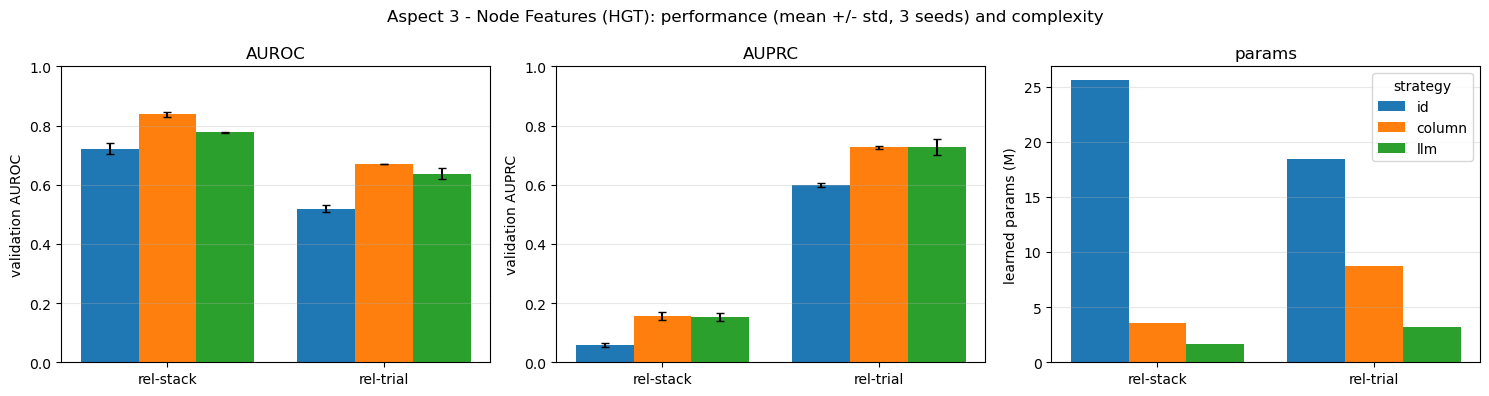

,strategy,implementation,extra dependency,preprocessing / storage cost,ease of use
0,id,trivial (an embedding table),none,"none (per-graph, not transferable)",very easy
1,column,torch_frame stype encoders,torch_frame,modest (typed columns),easy
2,llm,serialize row + MiniLM embed,sentence-transformers,heavy one-off embedding + storage,moderate


In [12]:
# ---------- Aspect 3 figure: performance (mean +/- std over 3 seeds) + complexity ----------
a3 = pd.read_csv(os.path.join(ARTIFACTS, "aspect3_results.csv"))
_ds = list(dict.fromkeys(a3["dataset"])); _st = ["id", "column", "llm"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(_ds)); w = 0.8 / len(_st)
for c, (col, ylab) in enumerate([("AUROC", "validation AUROC"), ("AUPRC", "validation AUPRC"),
                                 ("params", "learned params (M)")]):
    ax = axes[c]
    for i, s in enumerate(_st):
        g = a3[a3.strategy == s].groupby("dataset")[col]
        mu = [g.mean().get(d, np.nan) for d in _ds]
        if col == "params":
            ax.bar(x + i * w - 0.4 + w / 2, [v / 1e6 for v in mu], w, label=s)
        else:
            sd = [g.std().get(d, 0.0) for d in _ds]
            ax.bar(x + i * w - 0.4 + w / 2, mu, w, yerr=sd, capsize=3, label=s)
    ax.set_xticks(x); ax.set_xticklabels(_ds); ax.set_title(col); ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.3)
    if col != "params":
        ax.set_ylim(0, 1)
axes[-1].legend(title="strategy")
fig.suptitle("Aspect 3 - Node Features (HGT): performance (mean +/- std, 3 seeds) and complexity")
fig.tight_layout()
fig.savefig(os.path.join(ARTIFACTS, "aspect3_metrics.png"), dpi=130, bbox_inches="tight")
plt.show()

# usability summary (qualitative)
usability = pd.DataFrame([
    ["id",     "trivial (an embedding table)", "none",                  "none (per-graph, not transferable)", "very easy"],
    ["column", "torch_frame stype encoders",   "torch_frame",           "modest (typed columns)",             "easy"],
    ["llm",    "serialize row + MiniLM embed", "sentence-transformers", "heavy one-off embedding + storage",  "moderate"],
], columns=["strategy", "implementation", "extra dependency", "preprocessing / storage cost", "ease of use"])
usability


### Aspect 3 - Key results (mean +/- std over 3 seeds)

| dataset | strategy | AUROC | AUPRC | learned params |
|---|---|---|---|---|
| rel-stack | id | 0.722 +/- 0.018 | 0.058 | 25.6M |
| rel-stack | column | **0.838 +/- 0.008** | 0.156 | 3.6M |
| rel-stack | llm | 0.777 +/- 0.001 | 0.153 | 1.6M |
| rel-trial | id | 0.519 +/- 0.012 | 0.599 | 18.4M |
| rel-trial | column | **0.670 +/- 0.001** | 0.727 | 8.8M |
| rel-trial | llm | 0.637 +/- 0.018 | 0.727 | 3.2M |

- Clean, consistent ordering on both datasets: **column > llm > id**.
- id is near chance on rel-trial (transductive embeddings cannot generalize to unseen studies) but reaches 0.72 on rel-stack - graph structure alone carries engagement signal.
- llm's margin over id roughly doubles on text-heavy rel-trial (+0.12 vs +0.06), matching the expectation that language-model features pay off on text; it still trails column-wise, which keeps the numeric/categorical structure the row-to-string serialization destroys.
- Complexity: id has by far the most parameters (an embedding per node - scales with the sample, not comparable across datasets); llm the fewest learned parameters but the heaviest preprocessing; column in between (scales with the schema). Usability table above.

Full discussion: report.md section 5.

## Aspect 4 - Depth / Oversmoothing (report section 6)

**GCN** depth sweep L in {1,2,3,4,6,8} on a **fixed 2-hop sampled subgraph** (fan-out [10,10]; depth varies only the propagation rounds, which isolates depth and bounds memory), with and without **skip connections** (`relu(x + conv(x))`).

Oversmoothing measured on a fixed validation batch by two similarity metrics in the spirit of tutorial 7 (global mean pairwise cosine of a node sample, and mean squared distance of L2-normalized connected pairs - labelled `cos_sim` / `dir_energy`; not the tutorial's exact formulas, see report), plus the four downstream metrics vs depth. Same converged budget as the other aspects (30 epochs, patience 6, 1000 steps/epoch). Resumable; reuses the setup + `evaluate` harness.

In [13]:
# ---------- Aspect 4: GCN oversmoothing model + smoothing metrics ----------
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

A4_DEPTHS = [1, 2, 3, 4, 6, 8]
A4_SKIPS = [False, True]
A4_FANOUT = 10                     # fixed 2-hop subgraph; depth varies only the number of GCN layers
A4_BATCH = 256
A4_EPOCHS, A4_PATIENCE, A4_MAX_STEPS = 30, 6, 1000

def a4_collapse(x_dict, edge_index_dict, node_types):
    offsets = {}; xs = []; off = 0
    for nt in node_types:
        offsets[nt] = off; xs.append(x_dict[nt]); off += x_dict[nt].size(0)
    x_all = torch.cat(xs, dim=0); eis = []
    for (s, rel, d), ei in edge_index_dict.items():
        if ei.numel() == 0:
            continue
        eis.append(torch.stack([ei[0] + offsets[s], ei[1] + offsets[d]], dim=0))
    ei_all = torch.cat(eis, dim=1) if eis else torch.zeros(2, 0, dtype=torch.long, device=x_all.device)
    return x_all, ei_all, offsets

class OversmoothGCN(nn.Module):
    def __init__(self, data, col_stats, channels, num_layers, skip=False):
        super().__init__()
        self.encoder = HeteroEncoder(
            channels, {nt: data[nt].tf.col_names_dict for nt in data.node_types}, col_stats)
        self.node_types = list(data.node_types); self.skip = skip
        self.convs = nn.ModuleList([GCNConv(channels, channels) for _ in range(num_layers)])
        self.head = nn.Sequential(nn.Linear(channels, channels), nn.ReLU(), nn.Linear(channels, 1))

    def forward(self, batch, entity_table, return_nodes=False):
        x = self.encoder(batch.tf_dict)
        x_all, ei_all, offs = a4_collapse(x, batch.edge_index_dict, self.node_types)
        for conv in self.convs:
            h = conv(x_all, ei_all)
            x_all = torch.relu(x_all + h) if self.skip else torch.relu(h)   # residual skip connection
        if return_nodes:
            return x_all, ei_all
        o0 = offs[entity_table]; ent = x_all[o0:o0 + x[entity_table].size(0)]
        store = batch[entity_table]; n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(ent[:n]).squeeze(-1)

@torch.no_grad()
def smoothing_metrics(emb, edge_index, sample=4000):
    # Two oversmoothing indicators (in the spirit of tutorial 7, not its exact formulas):
    #   cos_sim    = global mean pairwise cosine similarity over a random node sample (-> 1)
    #   dir_energy = mean ||z_i - z_j||^2 over EDGES with L2-normalized z (-> 0); this equals
    #                2*(1 - mean neighbour cosine), a neighbour (1-cos) quantity, NOT the
    #                raw-embedding Dirichlet energy.
    z = F.normalize(emb, dim=1)
    if edge_index.numel() > 0:
        s, d = edge_index
        dir_energy = (z[s] - z[d]).pow(2).sum(1).mean().item()
    else:
        dir_energy = float("nan")
    idx = torch.randperm(z.size(0), device=z.device)[:min(sample, z.size(0))]
    cos_sim = (z[idx] @ z[idx].t()).mean().item()
    return cos_sim, dir_energy

def make_depth_loader(data, task, split, shuffle):
    ti = get_node_train_table_input(table=task.get_table(split), task=task)
    return NeighborLoader(data, num_neighbors=[A4_FANOUT, A4_FANOUT], time_attr="time",
        input_nodes=ti.nodes, input_time=ti.time, transform=ti.transform,
        batch_size=A4_BATCH, temporal_strategy="uniform", shuffle=shuffle, num_workers=0)

def train_a4(model, train_loader, val_loader, entity_table, pos_weight, on_epoch=None,
             epochs=None, patience=None, lr=None, max_steps=None):
    epochs = A4_EPOCHS if epochs is None else epochs
    patience = A4_PATIENCE if patience is None else patience
    lr = LR if lr is None else lr
    max_steps = A4_MAX_STEPS if max_steps is None else max_steps
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        train_losses = []
        for i, batch in enumerate(train_loader):
            if i >= max_steps:
                break
            batch = batch.to(device); opt.zero_grad()
            logit = model(batch, entity_table)
            loss = loss_fn(logit, batch[entity_table].y.float())
            loss.backward(); opt.step()
            if on_epoch is not None:
                train_losses.append(loss.item())
        m = evaluate(model, val_loader, entity_table, loss_fn=loss_fn if on_epoch is not None else None)
        if on_epoch is not None:
            on_epoch(dict(epoch=ep + 1, train_loss=float(np.mean(train_losses)),
                          val_loss=m["loss"], val_AUROC=m["AUROC"]))
        if m["AUROC"] > best:
            best = m["AUROC"]; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [14]:
# ---------- Aspect 4: depth sweep with/without skips (3 seeds on rel-trial; resumable) ----------
csv_path = os.path.join(ARTIFACTS, "aspect4_results.csv")
lc_start = lc_logger(os.path.join(ARTIFACTS, "loss_curves_A4.csv"))
if os.path.exists(csv_path):
    _prev = pd.read_csv(csv_path)
    if "seed" not in _prev.columns:
        _prev["seed"] = SEED            # migrate pre-multi-seed results
    results4 = _prev.to_dict("records")
else:
    results4 = []
done = {(r["dataset"], bool(r["skip"]), int(r["depth"]), int(r["seed"])) for r in results4}

for dataset_name, task_name in TASKS:
    todo = [(sk, L, sd) for sk in A4_SKIPS for L in A4_DEPTHS
            for sd in seeds_for(dataset_name) if (dataset_name, sk, L, sd) not in done]
    if not todo:
        print(f"{dataset_name}: all depths cached, skipping"); continue
    print(f"\n##### {dataset_name} / {task_name} ##### ({len(todo)} runs)")
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True)
    et = task.entity_table
    train_loader = make_depth_loader(data, task, "train", True)
    val_loader = make_depth_loader(data, task, "val", False)
    set_seed(SEED)
    smooth_batch = next(iter(val_loader)).to(device)     # fixed batch for the smoothing metrics (seeded)
    pw = pos_weight_of(task)
    for skip, L, sd in todo:
        set_seed(sd)
        model = OversmoothGCN(data, col_stats, HIDDEN, L, skip).to(device)
        t0 = time.time()
        model = train_a4(model, train_loader, val_loader, et, pw,
                         on_epoch=lc_start(dataset_name, f"L{L}{'-skip' if skip else ''}", sd))
        m = evaluate(model, val_loader, et)
        model.eval()
        with torch.no_grad():
            emb, ei = model(smooth_batch, et, return_nodes=True)
        cos_sim, dir_energy = smoothing_metrics(emb, ei)
        m.update(dataset=dataset_name, skip=skip, depth=L, seed=sd, cos_sim=cos_sim,
                 dir_energy=dir_energy, params=sum(p.numel() for p in model.parameters()),
                 train_s=time.time() - t0)
        results4.append(m); done.add((dataset_name, skip, L, sd))
        pd.DataFrame(results4).to_csv(csv_path, index=False)
        print(f"  skip={str(skip):5s} L={L:<2d} seed={sd} AUROC={m['AUROC']:.4f} "
              f"AUPRC={m['AUPRC']:.4f} cos={cos_sim:.3f} dirE={dir_energy:.3f} t={m['train_s']:.0f}s")
        del model; gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
    del data, col_stats, train_loader, val_loader, smooth_batch; gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

results4_df = pd.DataFrame(results4)[
    ["dataset", "skip", "depth", "seed", "AUROC", "AUPRC", "precision", "recall",
     "cos_sim", "dir_energy", "params", "train_s"]]
results4_df.to_csv(csv_path, index=False)
(results4_df.groupby(["dataset", "skip", "depth"])
 .agg(AUROC=("AUROC", "mean"), AUROC_std=("AUROC", "std"),
      cos_sim=("cos_sim", "mean"), dir_energy=("dir_energy", "mean")).round(4))


rel-stack: all depths cached, skipping
rel-trial: all depths cached, skipping


AUROC  AUROC_std  cos_sim  dir_energy
dataset   skip  depth                                        
rel-stack False 1      0.8639        NaN   0.4982      0.6777
                2      0.8579        NaN   0.7805      0.2123
                3      0.8626        NaN   0.7564      0.1801
                4      0.8622        NaN   0.7951      0.1496
                6      0.8629        NaN   0.8062      0.1875
                8      0.8568        NaN   0.7920      0.2673
          True  1      0.8581        NaN   0.5888      0.6683
                2      0.8642        NaN   0.6105      0.4793
                3      0.8639        NaN   0.5595      0.5546
                4      0.8616        NaN   0.7032      0.3607
                6      0.8642        NaN   0.7257      0.3391
                8      0.8708        NaN   0.6964      0.3630
rel-trial False 1      0.6690     0.0028   0.3941      0.7917
                2      0.6813     0.0020   0.5284      0.3734
                3      0.6836     0.0041   0.5945      0.2477
                4      0.6820     0.0064   0.6418      0.2042
                6      0.6689     0.0046   0.6400      0.2107
                8      0.6774     0.0006   0.6038      0.2112
          True  1      0.6693     0.0012   0.4059      1.1833
                2      0.6781     0.0050   0.4737      0.7352
                3      0.6789     0.0018   0.4999      0.6721
                4      0.6832     0.0075   0.5495      0.5637
                6      0.6776     0.0066   0.6922      0.3621
                8      0.6772     0.0035   0.7353      0.2584

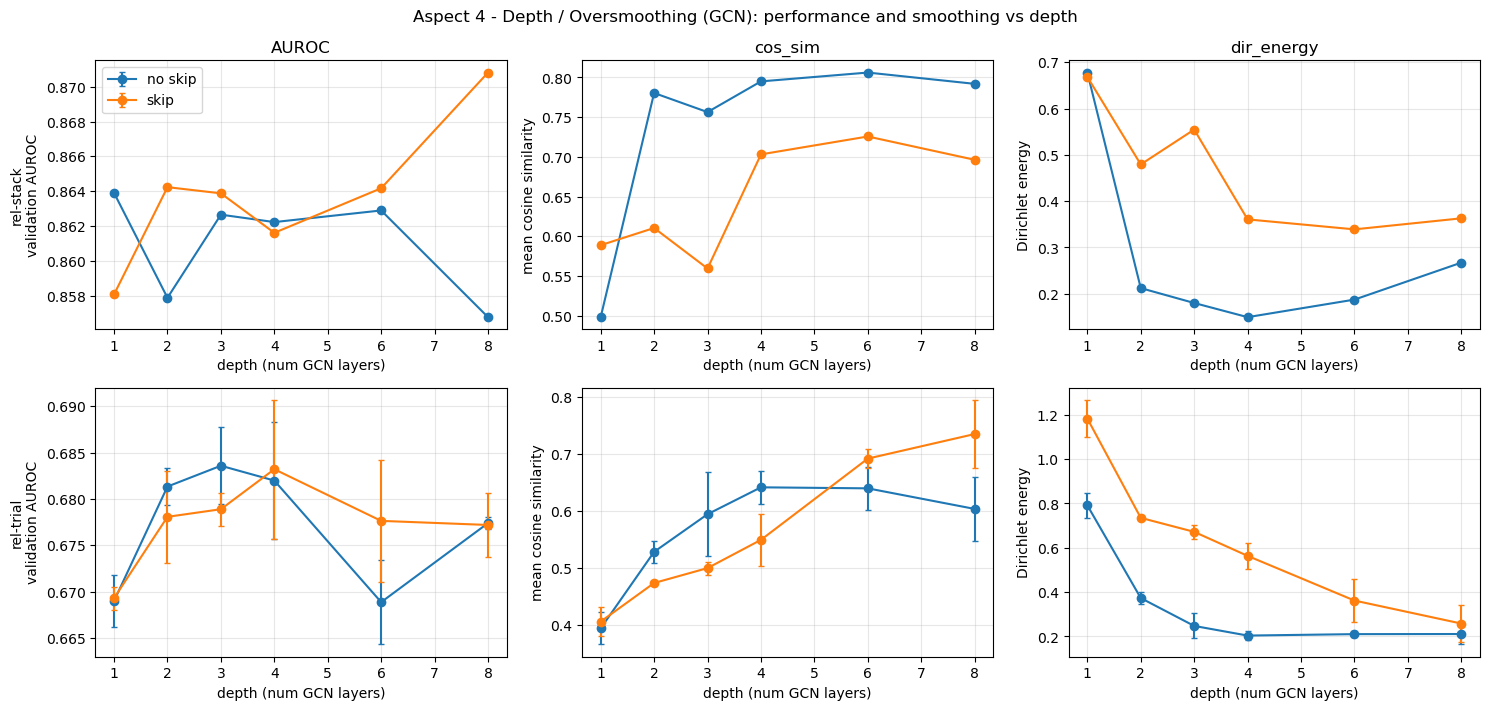

In [15]:
# ---------- Aspect 4 figure: performance and smoothing vs depth (skip vs no-skip) ----------
a4 = pd.read_csv(os.path.join(ARTIFACTS, "aspect4_results.csv"))
_datasets = list(dict.fromkeys(a4["dataset"]))
_panels = [("AUROC", "validation AUROC"), ("cos_sim", "mean cosine similarity"),
           ("dir_energy", "Dirichlet energy")]
fig, axes = plt.subplots(len(_datasets), len(_panels), figsize=(5 * len(_panels), 3.6 * len(_datasets)))
if len(_datasets) == 1:
    axes = axes[None, :]
for r, ds in enumerate(_datasets):
    sub = a4[a4.dataset == ds]
    for c, (col, ylab) in enumerate(_panels):
        ax = axes[r][c]
        for skip in [False, True]:
            s = sub[sub.skip == skip].groupby("depth")[col].agg(["mean", "std"]).reset_index()
            ax.errorbar(s["depth"], s["mean"], yerr=s["std"].fillna(0.0), marker="o",
                        capsize=2, label=("skip" if skip else "no skip"))
        ax.set_xlabel("depth (num GCN layers)"); ax.grid(alpha=0.3)
        ax.set_ylabel(f"{ds}\n{ylab}" if c == 0 else ylab)
        if r == 0:
            ax.set_title(col)
        if r == 0 and c == 0:
            ax.legend()
fig.suptitle("Aspect 4 - Depth / Oversmoothing (GCN): performance and smoothing vs depth")
fig.tight_layout()
fig.savefig(os.path.join(ARTIFACTS, "aspect4_metrics.png"), dpi=130, bbox_inches="tight")
plt.show()


### Aspect 4 - Key results

- Representations **do oversmooth** with depth: rel-stack cosine 0.50 -> ~0.80, neighbour energy 0.68 -> ~0.15 (rel-trial, mean of 3 seeds: cosine 0.39 -> ~0.64, energy 0.79 -> ~0.21).
- **Skip connections reduce the collapse**: neighbour energy is higher with skips at every depth on both datasets; cosine is kept lower on rel-stack (rel-trial's cosine is noisier and crosses at depth 8).
- **But downstream AUROC stays ~flat** (rel-stack ~0.86, rel-trial ~0.67-0.68 at all depths). The only clear skip win is rel-stack at L=8 (0.871 vs 0.857); on rel-trial the skip effect is within seed noise. Explanation: fixed receptive field + early stopping - representational collapse does not automatically become a performance problem.

Full discussion and caveats: report.md section 6.

**Historical section:** this diagnostic ran under the original 10-epoch protocol (its data is archived in `loss_curves_10ep.csv`). The official run cells now log curves themselves under the converged 30-epoch protocol.

## Supplementary: Loss Curves (exact-protocol under/overfitting diagnostic)

Reruns every configuration **exactly as the official run cells do**: same seeds
(`seeds_for(dataset)` - 1 seed on rel-stack, 3 on rel-trial; Aspect 3 uses `A3_SEEDS`
on both datasets), same epoch budgets, same early stopping (patience), same models
and loaders. The only addition is per-epoch train loss / val loss / val AUROC logging
via an `on_epoch` callback on the shared `train_model` / `train_a4` functions (a
backward-compatible optional argument - the official result cells above are
unaffected). Logs go to `artifacts/loss_curves.csv`, resumable per (aspect, dataset,
variant, seed): a run is only considered finished once it has a row marked `done`;
anything interrupted by a crash is discarded and retrained from scratch on rerun.

Because this reproduces the full experiment with logging, it costs about as much
compute as the original runs did. Run the model-defining cells first: aspect1-1,
aspect1-2, aspect1-3, aspect2-1, aspect3-1, aspect4-1.

In [16]:
# ---------- Supplementary: exact-protocol loss-curve logging (resumable) ----------
LC_PATH = os.path.join(ARTIFACTS, "loss_curves.csv")
rows = pd.read_csv(LC_PATH).to_dict("records") if os.path.exists(LC_PATH) else []

def _finished_keys():
    return {(r["aspect"], r["dataset"], r["variant"], int(r["seed"]))
            for r in rows if r.get("done") is True}

def _drop_unfinished():
    global rows
    fin = _finished_keys()
    rows = [r for r in rows
            if (r["aspect"], r["dataset"], r["variant"], int(r["seed"])) in fin]

_drop_unfinished()

def _make_on_epoch(aspect, dataset, variant, seed):
    def cb(d):
        d.update(aspect=aspect, dataset=dataset, variant=variant, seed=seed, done=False)
        rows.append(d)
        pd.DataFrame(rows).to_csv(LC_PATH, index=False)
    return cb

def _mark_done(aspect, dataset, variant, seed):
    key = (aspect, dataset, variant, seed)
    for r in reversed(rows):
        if (r["aspect"], r["dataset"], r["variant"], int(r["seed"])) == key:
            r["done"] = True
            break
    pd.DataFrame(rows).to_csv(LC_PATH, index=False)

# ===== A1 + A2 + A4 share the same loaded graph per dataset (mirrors the memory
# management already used in aspect1-4 / aspect2-2 / aspect4-2) =====
for dataset_name, task_name in TASKS:
    fin = _finished_keys()
    a1_todo = [("A1", bb, mode, sd) for bb in BACKBONES for mode in MODES
               for sd in seeds_for(dataset_name)
               if ("A1", dataset_name, f"{bb}-{mode}", sd) not in fin]
    a2_todo = [("A2", f, h, sd) for f, h in [("SAGE", False), ("SAGE", True), ("HGT", False), ("HGT", True)]
               for sd in seeds_for(dataset_name)
               if ("A2", dataset_name, f"{f}-{'hetero' if h else 'homo'}", sd) not in fin]
    a4_todo = [("A4", sk, L, sd) for sk in A4_SKIPS for L in A4_DEPTHS
               for sd in seeds_for(dataset_name)
               if ("A4", dataset_name, f"L{L}{'-skip' if sk else ''}", sd) not in fin]
    if not (a1_todo or a2_todo or a4_todo):
        print(f"{dataset_name}: all A1/A2/A4 loss curves cached, skipping"); continue
    print(f"\n##### {dataset_name}: A1={len(a1_todo)} A2={len(a2_todo)} A4={len(a4_todo)} runs #####")
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True); et = task.entity_table
    pw = pos_weight_of(task)

    if a1_todo:
        tl = make_loader(data, task, "train", shuffle=True)
        vl = make_loader(data, task, "val", shuffle=False)
        for _, bb, mode, sd in a1_todo:
            variant = f"{bb}-{mode}"
            print(f"  A1 {variant} seed={sd}")
            set_seed(sd)
            model = DirectionalModel(data, col_stats, HIDDEN, NUM_LAYERS, mode, bb).to(device)
            model = train_model(model, tl, vl, et, pw,
                                on_epoch=_make_on_epoch("A1", dataset_name, variant, sd))
            _mark_done("A1", dataset_name, variant, sd)
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()
        del tl, vl; gc.collect()

    if a2_todo:
        tl = make_loader(data, task, "train", shuffle=True)
        vl = make_loader(data, task, "val", shuffle=False)
        for _, fam, het, sd in a2_todo:
            variant = f"{fam}-{'hetero' if het else 'homo'}"
            print(f"  A2 {variant} seed={sd}")
            set_seed(sd)
            model = Aspect2Model(data, col_stats, HIDDEN, NUM_LAYERS, fam, het, heads=HEADS).to(device)
            model = train_model(model, tl, vl, et, pw,
                                on_epoch=_make_on_epoch("A2", dataset_name, variant, sd))
            _mark_done("A2", dataset_name, variant, sd)
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()
        del tl, vl; gc.collect()

    if a4_todo:
        tl4 = make_depth_loader(data, task, "train", True)
        vl4 = make_depth_loader(data, task, "val", False)
        for _, sk, L, sd in a4_todo:
            variant = f"L{L}{'-skip' if sk else ''}"
            print(f"  A4 {variant} seed={sd}")
            set_seed(sd)
            model = OversmoothGCN(data, col_stats, HIDDEN, L, sk).to(device)
            model = train_a4(model, tl4, vl4, et, pw,
                             on_epoch=_make_on_epoch("A4", dataset_name, variant, sd))
            _mark_done("A4", dataset_name, variant, sd)
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()
        del tl4, vl4; gc.collect()

    del data, col_stats; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

# ===== A3: uses its own cached subgraph, independent of the loop above =====
for dataset_name, task_name in TASKS:
    fin = _finished_keys()
    todo = [(s, sd) for s in ["id", "column", "llm"] for sd in A3_SEEDS
            if ("A3", dataset_name, s, sd) not in fin]
    if not todo:
        print(f"{dataset_name}: A3 loss curves cached, skipping"); continue
    print(f"\n##### {dataset_name}: A3={len(todo)} runs #####")
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    blob = a3_build_or_load(dataset_name, task_name)
    sub, split, et = blob["sub"], blob["split"], blob["entity_table"]
    tl3, vl3 = a3_loaders(blob)
    ytr = sub[et].y[:blob["n_seed"]][split]
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum().item(), 1.0)], device=device)
    for strat, sd in todo:
        print(f"  A3 {strat} seed={sd}")
        set_seed(sd)
        model = A3Model(sub, blob["col_stats"], HIDDEN, NUM_LAYERS, strat, blob["llm_dim"]).to(device)
        model = train_model(model, tl3, vl3, et, pw,
                            on_epoch=_make_on_epoch("A3", dataset_name, strat, sd))
        _mark_done("A3", dataset_name, strat, sd)
        del model; gc.collect()
        if device.type == "cuda": torch.cuda.empty_cache()
    del blob, sub, tl3, vl3; gc.collect()

print("\nloss-curve logging complete:", len(rows), "epoch-rows,", len(_finished_keys()), "finished runs")


rel-stack: all A1/A2/A4 loss curves cached, skipping
rel-trial: all A1/A2/A4 loss curves cached, skipping
rel-stack: A3 loss curves cached, skipping
rel-trial: A3 loss curves cached, skipping

loss-curve logging complete: 706 epoch-rows, 106 finished runs


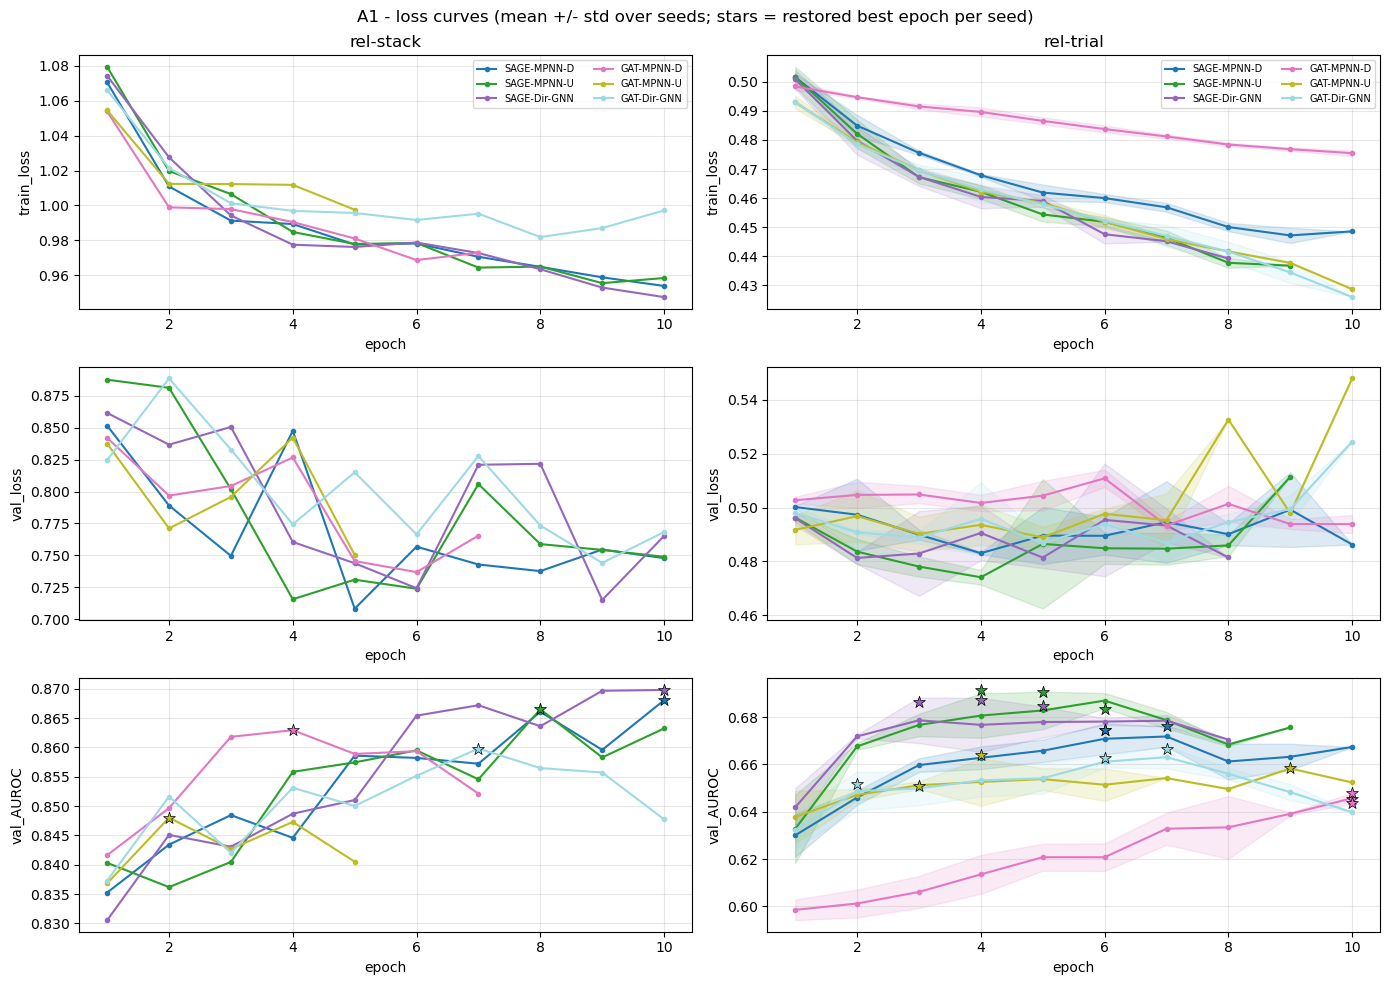

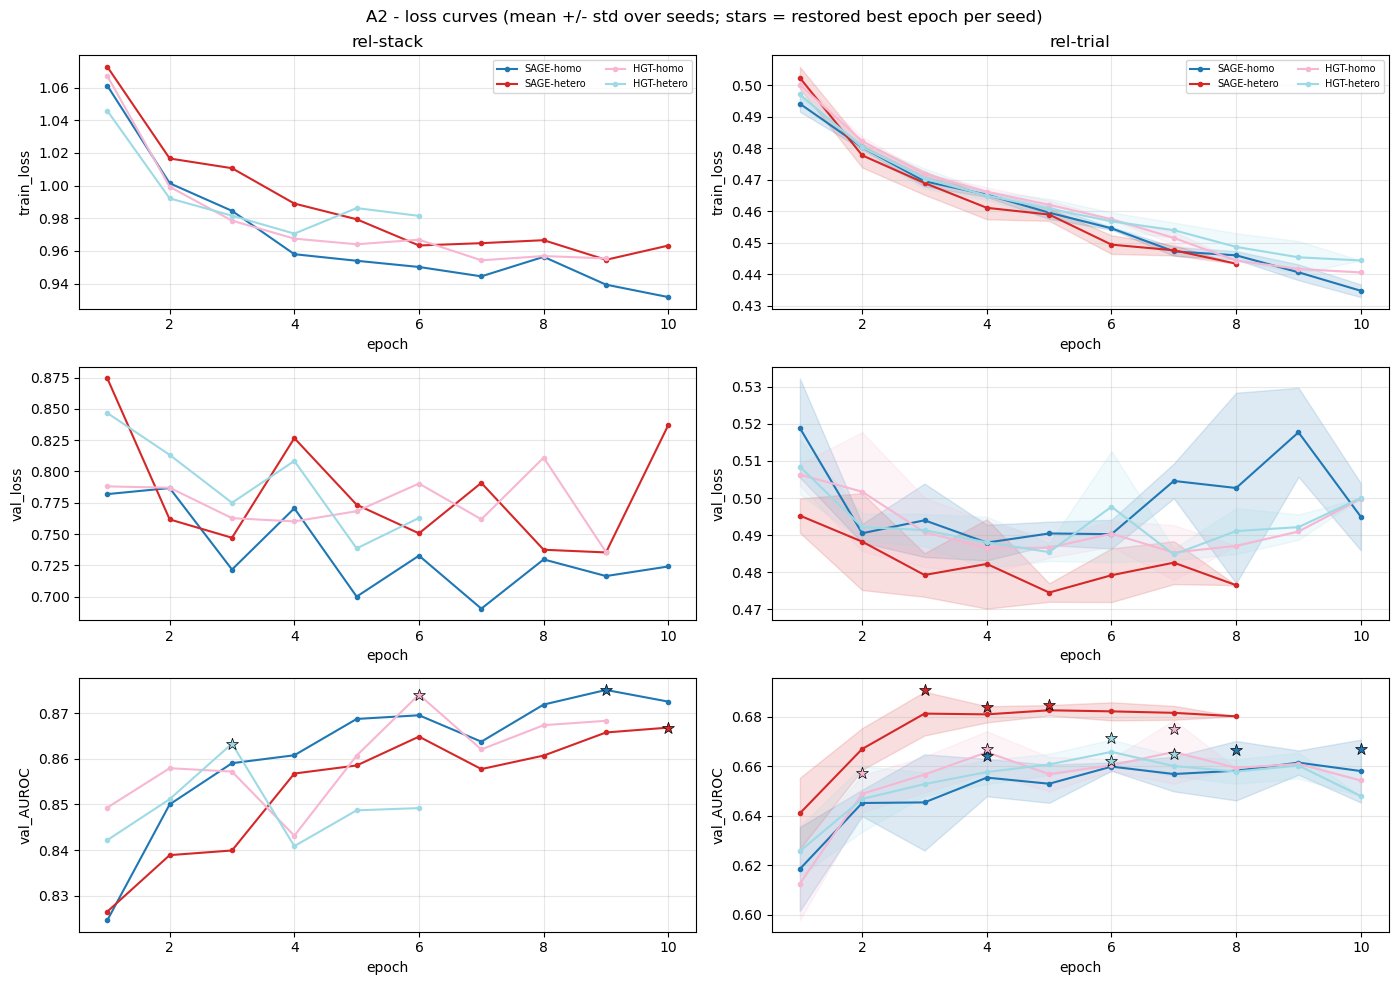

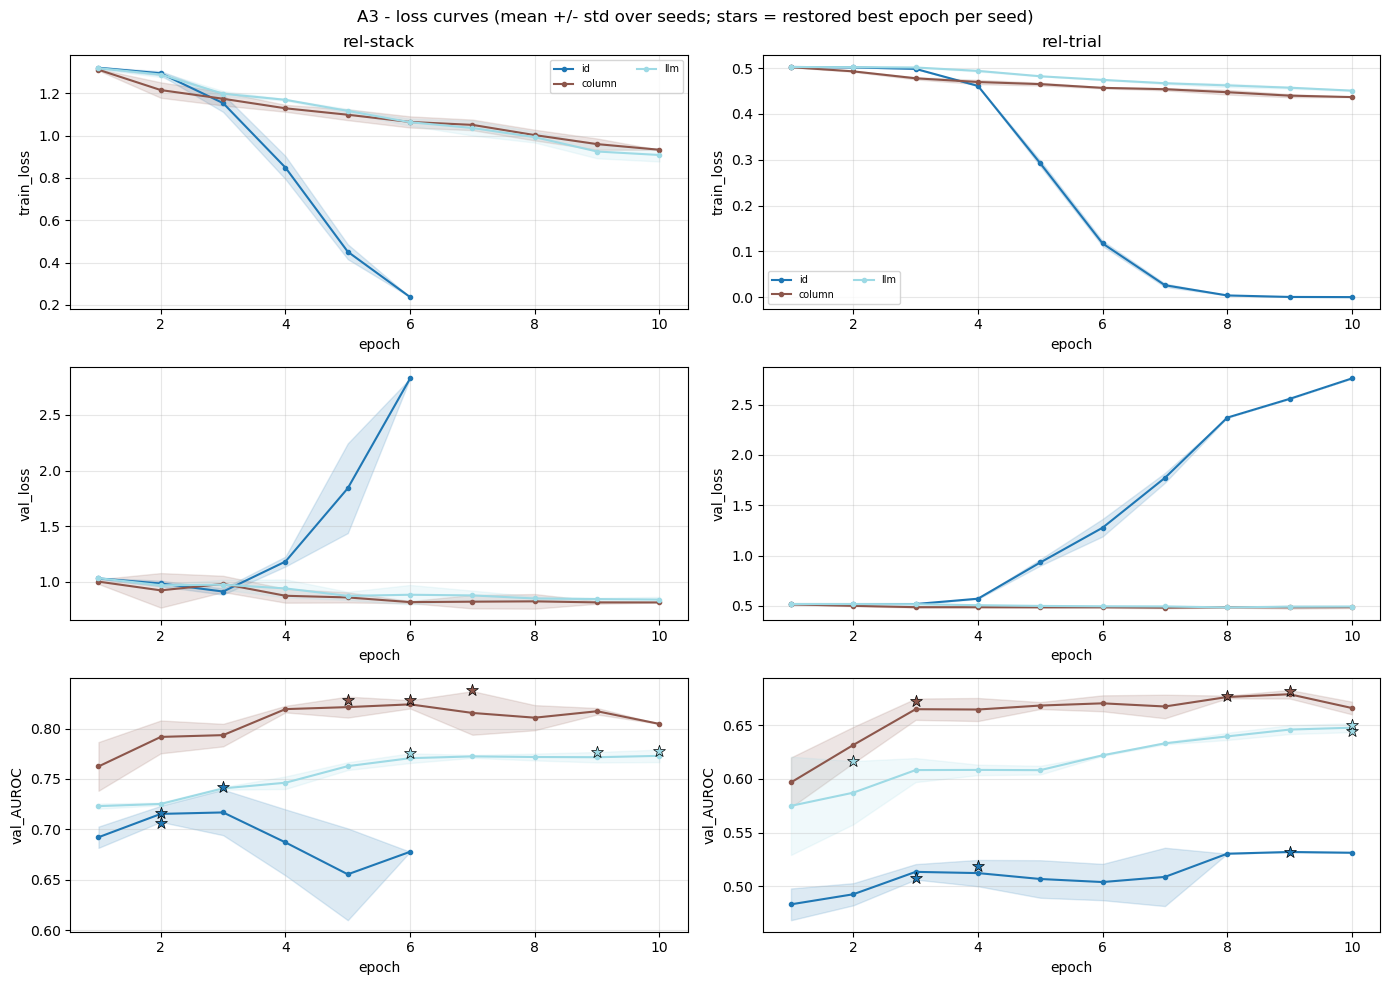

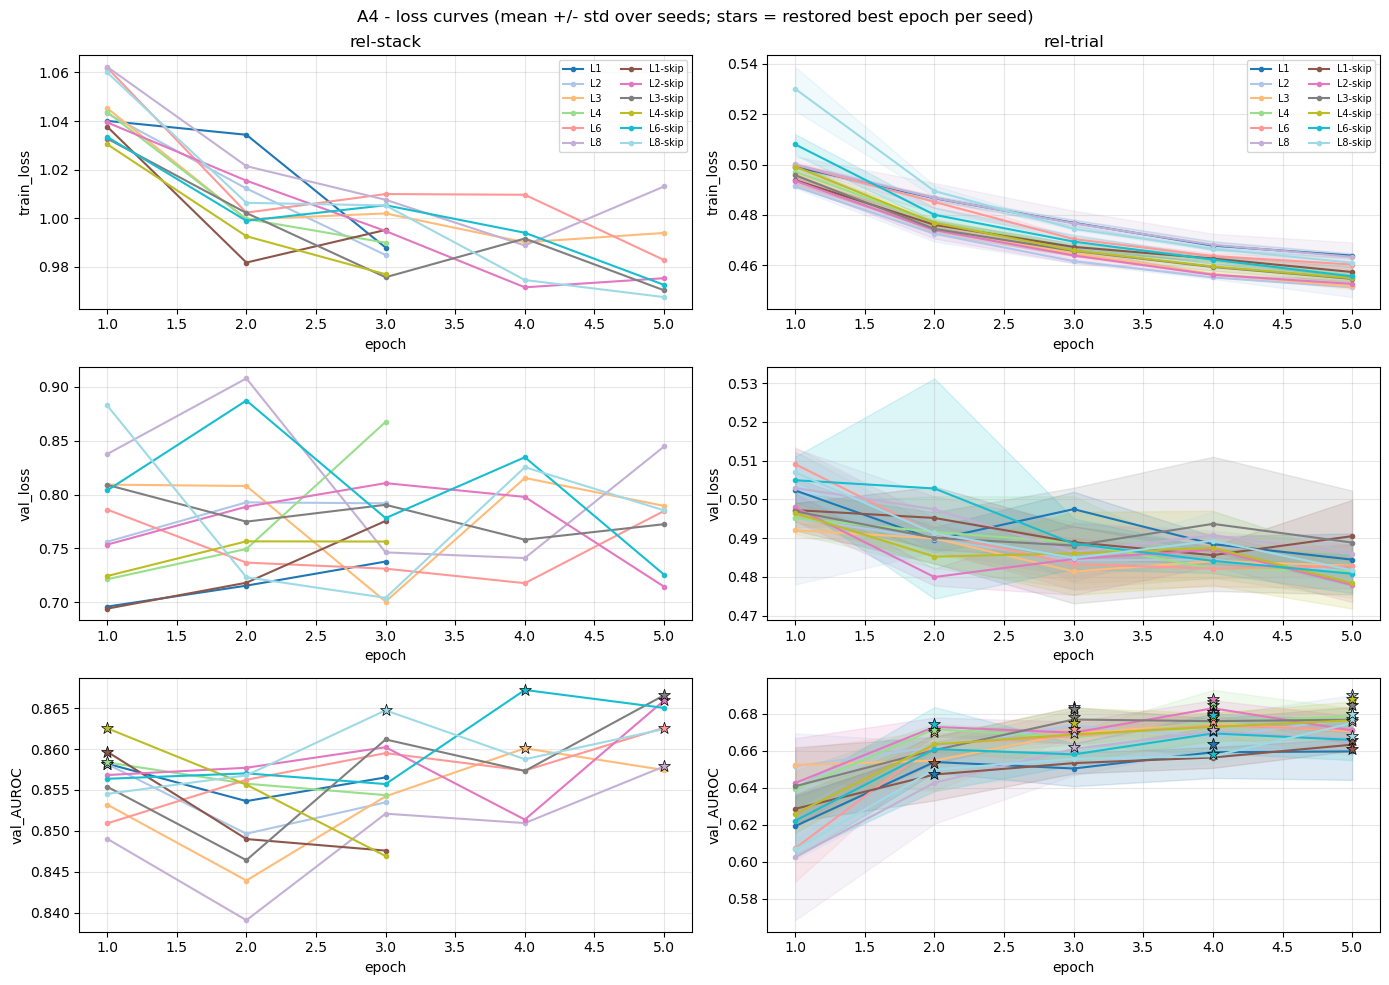

In [17]:
# ---------- Supplementary figure: mean +/- std loss curves per aspect, with stop markers ----------
lc = pd.read_csv(os.path.join(ARTIFACTS, "loss_curves.csv"))
if "done" in lc.columns:
    # keep the FULL epoch trajectory for any run that finished (not just its done=True row)
    finished = lc.loc[lc["done"] == True, ["aspect", "dataset", "variant", "seed"]].drop_duplicates()
    lc = lc.merge(finished, on=["aspect", "dataset", "variant", "seed"], how="inner")
for aspect in ["A1", "A2", "A3", "A4"]:
    sub = lc[lc.aspect == aspect]
    if sub.empty: continue
    dss = list(dict.fromkeys(sub.dataset))
    fig, axes = plt.subplots(3, len(dss), figsize=(7 * len(dss), 10), squeeze=False)
    for c, ds in enumerate(dss):
        d = sub[sub.dataset == ds]
        variants = list(dict.fromkeys(d.variant))
        cmap = plt.cm.tab20(np.linspace(0, 1, max(len(variants), 2)))
        for r, col in enumerate(["train_loss", "val_loss", "val_AUROC"]):
            ax = axes[r][c]
            for i, v in enumerate(variants):
                dv = d[d.variant == v]
                g = dv.groupby("epoch")[col]
                mean = g.mean(); std = g.std().fillna(0.0); n = g.count()
                ax.plot(mean.index, mean.values, marker=".", color=cmap[i], label=v)
                if (n > 1).any():
                    ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                                    color=cmap[i], alpha=0.15)
                if col == "val_AUROC":
                    # mark the per-seed epoch each run actually stopped/restored-best at
                    stops = dv.loc[dv.groupby("seed")["val_AUROC"].idxmax()]
                    ax.scatter(stops["epoch"], stops["val_AUROC"], color=cmap[i], marker="*",
                              s=80, zorder=5, edgecolor="black", linewidth=0.5)
            ax.set_xlabel("epoch"); ax.set_ylabel(col); ax.grid(alpha=0.3)
            if r == 0: ax.set_title(ds)
        axes[0][c].legend(fontsize=7, ncol=2)
    fig.suptitle(f"{aspect} - loss curves (mean +/- std over seeds; stars = restored best epoch per seed)")
    fig.tight_layout()
    fig.savefig(os.path.join(ARTIFACTS, f"loss_curves_{aspect}.png"), dpi=120, bbox_inches="tight")
    plt.show()


**Historical section:** these checks investigated the original 10-epoch protocol's open questions and motivated the converged 30-epoch protocol that the official cells now use. Kept as evidence; do not rerun.

## Follow-up: Confirmatory Re-checks

Five open questions from the training-curve audit, re-tested directly. Everything here writes to two files, completely separate from the official results above:

- `artifacts/confirm_results.csv` - one row per finished run: final metrics plus `n_epochs`, `converged` (True = stopped by early stopping, False = hit the epoch budget) and `best_epoch` (the restored checkpoint).
- `artifacts/confirm_loss_curves.csv` - per-epoch train loss / val loss / val AUROC for every run.

**Resumability rule: a run whose final result is saved is never repeated.** The first 11 runs (check 1 and most of check 2) finished before curve logging was added, so they have final numbers but no curves; to redo any of them with curves, delete their rows from `confirm_results.csv` first (cheap for check 1, ~30 min per run for check 2 - not recommended).

The checks:
1. **A1 - GAT-MPNN-D, rel-trial:** never converged in 10 epochs. Does it catch up to MPNN-U / Dir-GNN with a longer budget (40 epochs) or a higher LR (3e-3)?
2. **A2 - SAGE homo vs hetero, rel-stack:** both were still improving at epoch 10. Does the homo-wins gap survive real convergence (30 epochs, 3 seeds)?
3. **A2 - aggregation choice:** hetero combines per-edge-type outputs with `sum`, homo uses a single `mean`. A hetero variant with `mean` combining tests whether the combine rule, not type-awareness, drives the gap (official 10-epoch budget, both datasets).
4. **A3 - llm, both datasets:** still improving at cutoff in most seeds. Longer budget (30) and, separately, a higher LR just for its projection layer.
5. **A4 - depth (L2 and L8, skip and no-skip):** all depth-sweep models were barely trained. Longer budget (30 epochs, 1000 steps/epoch).

Run the model cells first (aspect1-1, aspect1-2, aspect1-3, aspect2-1, aspect3-1, aspect4-1), then the shared-helpers cell below, then the check cells in any order.

In [18]:
# ---------- Confirmatory re-checks: shared infrastructure ----------
CONFIRM_PATH = os.path.join(ARTIFACTS, "confirm_results.csv")
CONFIRM_LC_PATH = os.path.join(ARTIFACTS, "confirm_loss_curves.csv")
confirm_rows = pd.read_csv(CONFIRM_PATH).to_dict("records") if os.path.exists(CONFIRM_PATH) else []
lc_rows = pd.read_csv(CONFIRM_LC_PATH).to_dict("records") if os.path.exists(CONFIRM_LC_PATH) else []
confirm_done = {(r["check"], r["dataset"], r["variant"], int(r["seed"])) for r in confirm_rows}

def _lc_key(r):
    return (r["check"], r["dataset"], r["variant"], int(r["seed"]))

# drop curve rows of runs that crashed mid-training (a crashed run restarts from scratch)
_lc_finished = {_lc_key(r) for r in lc_rows if r.get("done") is True}
lc_rows = [r for r in lc_rows if _lc_key(r) in _lc_finished]

def run_confirm(key, make_model, train_fn, epochs_budget, train_loader, val_loader, et, pw,
                **train_kwargs):
    """Train one confirmatory run with per-epoch curve logging; skip if its final
    result is already saved. key = (check, dataset, variant, seed)."""
    check, dataset, variant, seed = key
    if key in confirm_done:
        print(f"  {variant:18s} seed={seed}: cached, skip"); return
    lc_rows[:] = [r for r in lc_rows if _lc_key(r) != key]   # clear any stale partial curve
    def on_epoch(d):
        d.update(check=check, dataset=dataset, variant=variant, seed=seed, done=False)
        lc_rows.append(d)
        pd.DataFrame(lc_rows).to_csv(CONFIRM_LC_PATH, index=False)   # save every epoch
    set_seed(seed)
    model = make_model().to(device)
    t0 = time.time()
    model = train_fn(model, train_loader, val_loader, et, pw, on_epoch=on_epoch, **train_kwargs)
    curve = [r for r in lc_rows if _lc_key(r) == key]
    for r in reversed(lc_rows):                               # mark this run's curve finished
        if _lc_key(r) == key:
            r["done"] = True; break
    pd.DataFrame(lc_rows).to_csv(CONFIRM_LC_PATH, index=False)
    m = evaluate(model, val_loader, et)
    m["train_s"] = time.time() - t0
    m["n_epochs"] = len(curve)
    m["best_epoch"] = max(curve, key=lambda d: d["val_AUROC"])["epoch"] if curve else None
    m["converged"] = len(curve) < epochs_budget               # stopped by patience, not budget
    confirm_rows.append(dict(check=check, dataset=dataset, variant=variant, seed=seed, **m))
    pd.DataFrame(confirm_rows).to_csv(CONFIRM_PATH, index=False)
    confirm_done.add(key)
    print(f"  {variant:18s} seed={seed} AUROC={m['AUROC']:.4f} epochs={m['n_epochs']} "
          f"converged={m['converged']} best_ep={m['best_epoch']} t={m['train_s']:.0f}s")
    del model; gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()


In [19]:
# ---------- Confirm 1: A1 GAT-MPNN-D - longer training + higher LR (rel-trial) ----------
C1_EPOCHS, C1_PATIENCE, C1_HIGH_LR = 40, 8, 3e-3
todo = [(tag, lr, sd) for tag, lr in [("longer", None), ("higher_lr", C1_HIGH_LR)] for sd in [42, 43, 44]
        if ("A1_GAT_MPNN_D", "rel-trial", tag, sd) not in confirm_done]
if not todo:
    print("check 1: all cached, skipping")
else:
    torch_geometric.backend.use_segment_matmul = False
    data, col_stats = build_or_load_graph("rel-trial")
    task = get_task("rel-trial", "study-outcome", download=True); et = task.entity_table
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    for tag, lr, sd in todo:
        run_confirm(("A1_GAT_MPNN_D", "rel-trial", tag, sd),
                    lambda: DirectionalModel(data, col_stats, HIDDEN, NUM_LAYERS, "MPNN-D", "GAT"),
                    train_model, C1_EPOCHS, train_loader, val_loader, et, pw,
                    epochs=C1_EPOCHS, patience=C1_PATIENCE, lr=lr)
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

print("original GAT-MPNN-D (10ep):", pd.read_csv(os.path.join(ARTIFACTS, "aspect1_results.csv"))
      .query("dataset=='rel-trial' and backbone=='GAT' and mode=='MPNN-D'")["AUROC"].mean().round(4),
      "| other modes: MPNN-U", pd.read_csv(os.path.join(ARTIFACTS, "aspect1_results.csv"))
      .query("dataset=='rel-trial' and backbone=='GAT' and mode=='MPNN-U'")["AUROC"].mean().round(4))
pd.read_csv(CONFIRM_PATH).query("check == 'A1_GAT_MPNN_D'").groupby("variant")["AUROC"].agg(["mean", "std"]).round(4)


Loading Database object from /home/abed/.cache/relbench/rel-trial/db...
Done in 4.89 seconds.


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/relbench/modeling/graph.py:93: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /home/task_177834778478898/croot/libtorch_1778347831796/work/torch/csrc/utils/tensor_numpy.cpp:213.)
  pkey_index = torch.from_numpy(pkey_in

  longer             seed=42 AUROC=0.6525 epochs=18 converged=True best_ep=10 t=78s


/tmp/ipykernel_442678/3981239694.py:33: UserWarning: There exist node types ({'outcome_analyses', 'interventions_studies', 'designs', 'conditions_studies', 'eligibilities', 'drop_withdrawals', 'reported_event_totals', 'sponsors_studies', 'facilities_studies'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  return HeteroConv(convs, aggr="sum")


  longer             seed=43 AUROC=0.6415 epochs=21 converged=True best_ep=13 t=81s


...

/tmp/ipykernel_442678/3981239694.py:33: UserWarning: There exist node types ({'outcome_analyses', 'interventions_studies', 'designs', 'conditions_studies', 'eligibilities', 'drop_withdrawals', 'reported_event_totals', 'sponsors_studies', 'facilities_studies'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  return HeteroConv(convs, aggr="sum")


  higher_lr          seed=43 AUROC=0.6431 epochs=20 converged=True best_ep=12 t=77s


/tmp/ipykernel_442678/3981239694.py:33: UserWarning: There exist node types ({'outcome_analyses', 'interventions_studies', 'designs', 'conditions_studies', 'eligibilities', 'drop_withdrawals', 'reported_event_totals', 'sponsors_studies', 'facilities_studies'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  return HeteroConv(convs, aggr="sum")


  higher_lr          seed=44 AUROC=0.6500 epochs=20 converged=True best_ep=12 t=78s
original GAT-MPNN-D (10ep): 0.6301 | other modes: MPNN-U 0.6614


,mean,std
variant,,
higher_lr,0.6487,0.0051
longer,0.6484,0.0060


In [20]:
# ---------- Confirm 2+3: A2 - longer training (rel-stack) + mean-aggregation hetero ----------
C2_EPOCHS, C2_PATIENCE = 30, 6

class Aspect2MeanModel(nn.Module):
    # SAGE-hetero, but combining the per-edge-type outputs with mean instead of sum.
    # Tests whether sum's scale mismatch (nodes fed by many edge types get inflated,
    # summed representations), rather than type-awareness itself, was hurting hetero.
    def __init__(self, data, col_stats, ch, L):
        super().__init__()
        self.encoder = HeteroEncoder(
            ch, {nt: data[nt].tf.col_names_dict for nt in data.node_types}, col_stats)
        self.convs = nn.ModuleList([HeteroConv(
            {et: SAGEConv((ch, ch), ch, aggr="mean") for et in data.edge_types}, aggr="mean")
            for _ in range(L)])
        self.head = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, 1))
    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        for conv in self.convs:
            o = conv(x, batch.edge_index_dict)
            x = {nt: (torch.relu(o[nt]) if o.get(nt) is not None else x[nt]) for nt in x}
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(x[entity_table][:n]).squeeze(-1)

for dataset_name, task_name in TASKS:
    longer = ([("A2_homo_hetero_longer", dataset_name, v, sd)
               for sd in [42, 43, 44] for v in ["SAGE-homo", "SAGE-hetero"]]
              if dataset_name == "rel-stack" else [])
    meanagg = [("A2_mean_aggregation", dataset_name, "SAGE-hetero-mean", sd) for sd in [42, 43, 44]]
    todo = [k for k in longer + meanagg if k not in confirm_done]
    if not todo:
        print(f"{dataset_name}: checks 2+3 all cached, skipping"); continue
    print(f"\n##### {dataset_name} ({len(todo)} runs) #####")
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True); et = task.entity_table
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    for key in todo:
        if key[0] == "A2_homo_hetero_longer":
            hetero = key[2] == "SAGE-hetero"
            run_confirm(key,
                        lambda h=hetero: Aspect2Model(data, col_stats, HIDDEN, NUM_LAYERS, "SAGE", h, heads=HEADS),
                        train_model, C2_EPOCHS, train_loader, val_loader, et, pw,
                        epochs=C2_EPOCHS, patience=C2_PATIENCE)
        else:  # mean-aggregation variant, official 10-epoch budget for a like-for-like comparison
            run_confirm(key,
                        lambda: Aspect2MeanModel(data, col_stats, HIDDEN, NUM_LAYERS),
                        train_model, EPOCHS, train_loader, val_loader, et, pw)
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

c2 = pd.read_csv(CONFIRM_PATH)
print("\n--- check 2: longer training, rel-stack (original 10ep: homo 0.874, hetero 0.860) ---")
print(c2.query("check == 'A2_homo_hetero_longer'").groupby("variant")["AUROC"].agg(["mean", "std", "count"]).round(4))
print("\n--- check 3: hetero with mean-combining (official sum-hetero: rel-stack 0.860, rel-trial 0.692) ---")
print(c2.query("check == 'A2_mean_aggregation'").groupby("dataset")["AUROC"].agg(["mean", "std", "count"]).round(4))



##### rel-stack (9 runs) #####
Loading Database object from /home/abed/.cache/relbench/rel-stack/db...
Done in 8.04 seconds.


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your 

  SAGE-homo          seed=42 AUROC=0.8818 epochs=30 converged=False best_ep=28 t=1841s
  SAGE-hetero        seed=42 AUROC=0.8764 epochs=26 converged=True best_ep=20 t=2166s
  SAGE-homo          seed=43 AUROC=0.8795 epochs=28 converged=True best_ep=22 t=1708s
  SAGE-hetero        seed=43 AUROC=0.8772 epochs=22 converged=True best_ep=16 t=1661s
  SAGE-homo          seed=44 AUROC=0.8796 epochs=23 converged=True best_ep=17 t=1302s
  SAGE-hetero        seed=44 AUROC=0.8777 epochs=30 converged=False best_ep=26 t=2105s
  SAGE-hetero-mean   seed=42 AUROC=0.8643 epochs=10 converged=False best_ep=7 t=750s
  SAGE-hetero-mean   seed=43 AUROC=0.8678 epochs=10 converged=False best_ep=10 t=757s
  SAGE-hetero-mean   seed=44 AUROC=0.8656 epochs=10 converged=False best_ep=10 t=759s

##### rel-trial (3 runs) #####


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your 

  SAGE-hetero-mean   seed=42 AUROC=0.6862 epochs=10 converged=False best_ep=9 t=41s
  SAGE-hetero-mean   seed=43 AUROC=0.6897 epochs=6 converged=True best_ep=3 t=22s
  SAGE-hetero-mean   seed=44 AUROC=0.6792 epochs=6 converged=True best_ep=3 t=22s

--- check 2: longer training, rel-stack (original 10ep: homo 0.874, hetero 0.860) ---
               mean     std  count
variant                           
SAGE-hetero  0.8771  0.0007      3
SAGE-homo    0.8803  0.0013      3

--- check 3: hetero with mean-combining (official sum-hetero: rel-stack 0.860, rel-trial 0.692) ---
             mean     std  count
dataset                         
rel-stack  0.8659  0.0018      3
rel-trial  0.6850  0.0053      3


In [21]:
# ---------- Confirm 4: A3 llm - longer training + higher LR on the projection layer ----------
C3_EPOCHS, C3_PATIENCE, C3_HIGH_LR = 30, 6, 5e-3

def train_model_grouped_lr(model, train_loader, val_loader, entity_table, pos_weight,
                           on_epoch=None, epochs=C3_EPOCHS, patience=C3_PATIENCE,
                           group_prefix="proj.", high_lr=C3_HIGH_LR):
    # train_model's loop, but parameters whose name starts with group_prefix (the llm
    # strategy's projection layer) train at high_lr while everything else stays at LR.
    proj = [p for n, p in model.named_parameters() if n.startswith(group_prefix)]
    rest = [p for n, p in model.named_parameters() if not n.startswith(group_prefix)]
    opt = torch.optim.Adam([{"params": rest, "lr": LR}, {"params": proj, "lr": high_lr}])
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_auroc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        train_losses = []
        for i, batch in enumerate(train_loader):
            if MAX_STEPS_PER_EPOCH and i >= MAX_STEPS_PER_EPOCH:
                break
            batch = batch.to(device)
            opt.zero_grad()
            loss = loss_fn(model(batch, entity_table), batch[entity_table].y.float())
            loss.backward(); opt.step()
            if on_epoch is not None:
                train_losses.append(loss.item())
        m = evaluate(model, val_loader, entity_table, loss_fn=loss_fn if on_epoch is not None else None)
        if on_epoch is not None:
            on_epoch(dict(epoch=ep + 1, train_loss=float(np.mean(train_losses)),
                          val_loss=m["loss"], val_AUROC=m["AUROC"]))
        if m["AUROC"] > best_auroc:
            best_auroc = m["AUROC"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

for dataset_name, task_name in TASKS:
    todo = [(tag, sd) for tag in ["longer", "proj_high_lr"] for sd in A3_SEEDS
            if ("A3_llm", dataset_name, tag, sd) not in confirm_done]
    if not todo:
        print(f"{dataset_name}: check 4 all cached, skipping"); continue
    print(f"\n##### {dataset_name} ({len(todo)} runs) #####")
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    blob = a3_build_or_load(dataset_name, task_name)
    sub, split, et = blob["sub"], blob["split"], blob["entity_table"]
    train_loader, val_loader = a3_loaders(blob)
    ytr = sub[et].y[:blob["n_seed"]][split]
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum().item(), 1.0)], device=device)
    for tag, sd in todo:
        make = lambda: A3Model(sub, blob["col_stats"], HIDDEN, NUM_LAYERS, "llm", blob["llm_dim"])
        if tag == "longer":
            run_confirm(("A3_llm", dataset_name, tag, sd), make, train_model, C3_EPOCHS,
                        train_loader, val_loader, et, pw, epochs=C3_EPOCHS, patience=C3_PATIENCE)
        else:
            run_confirm(("A3_llm", dataset_name, tag, sd), make, train_model_grouped_lr, C3_EPOCHS,
                        train_loader, val_loader, et, pw)
    del blob, sub, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

print("original llm (10ep): rel-stack 0.777, rel-trial 0.637 | column: 0.838 / 0.670")
pd.read_csv(CONFIRM_PATH).query("check == 'A3_llm'").groupby(["dataset", "variant"])["AUROC"].agg(["mean", "std"]).round(4)



##### rel-stack (6 runs) #####
  longer             seed=42 AUROC=0.7813 epochs=17 converged=True best_ep=11 t=30s
  longer             seed=43 AUROC=0.7769 epochs=16 converged=True best_ep=10 t=18s
  longer             seed=44 AUROC=0.7769 epochs=16 converged=True best_ep=10 t=17s
  proj_high_lr       seed=42 AUROC=0.7763 epochs=16 converged=True best_ep=10 t=18s
  proj_high_lr       seed=43 AUROC=0.7769 epochs=13 converged=True best_ep=7 t=14s
  proj_high_lr       seed=44 AUROC=0.7847 epochs=14 converged=True best_ep=8 t=15s

##### rel-trial (6 runs) #####
  longer             seed=42 AUROC=0.6503 epochs=17 converged=True best_ep=11 t=49s
  longer             seed=43 AUROC=0.6559 epochs=18 converged=True best_ep=12 t=50s
  longer             seed=44 AUROC=0.6503 epochs=16 converged=True best_ep=10 t=44s
  proj_high_lr       seed=42 AUROC=0.6540 epochs=12 converged=True best_ep=6 t=33s
  proj_high_lr       seed=43 AUROC=0.6552 epochs=14 converged=True best_ep=8 t=38s
  proj_high_lr  

mean     std
dataset   variant                     
rel-stack longer        0.7784  0.0026
          proj_high_lr  0.7793  0.0047
rel-trial longer        0.6522  0.0032
          proj_high_lr  0.6525  0.0036

In [22]:
# ---------- Confirm 5: A4 depth - longer training at L2 and L8, skip and no-skip ----------
C4_EPOCHS, C4_PATIENCE, C4_MAX_STEPS = 30, 6, 1000
C4_DEPTHS = [2, 8]
for dataset_name, task_name in TASKS:
    todo = [(sk, L, sd) for sk in A4_SKIPS for L in C4_DEPTHS for sd in seeds_for(dataset_name)
            if ("A4_depth_longer", dataset_name, f"L{L}{'-skip' if sk else ''}", sd) not in confirm_done]
    if not todo:
        print(f"{dataset_name}: check 5 all cached, skipping"); continue
    print(f"\n##### {dataset_name} ({len(todo)} runs) #####")
    torch_geometric.backend.use_segment_matmul = False if dataset_name == "rel-trial" else None
    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True); et = task.entity_table
    train_loader = make_depth_loader(data, task, "train", True)
    val_loader = make_depth_loader(data, task, "val", False)
    pw = pos_weight_of(task)
    for sk, L, sd in todo:
        variant = f"L{L}{'-skip' if sk else ''}"
        run_confirm(("A4_depth_longer", dataset_name, variant, sd),
                    lambda s=sk, l=L: OversmoothGCN(data, col_stats, HIDDEN, l, s),
                    train_a4, C4_EPOCHS, train_loader, val_loader, et, pw,
                    epochs=C4_EPOCHS, patience=C4_PATIENCE, max_steps=C4_MAX_STEPS)
    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

print("original (5ep/300steps) means: rel-stack L2 0.858 / L8 0.857 / L8-skip 0.871; rel-trial ~0.67-0.68 all")
pd.read_csv(CONFIRM_PATH).query("check == 'A4_depth_longer'").groupby(["dataset", "variant"])["AUROC"].agg(["mean", "std"]).round(4)



##### rel-stack (4 runs) #####


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your 

  L2                 seed=42 AUROC=0.8790 epochs=13 converged=True best_ep=7 t=1160s
  L8                 seed=42 AUROC=0.8782 epochs=18 converged=True best_ep=12 t=1764s
  L2-skip            seed=42 AUROC=0.8842 epochs=30 converged=False best_ep=29 t=2668s
  L8-skip            seed=42 AUROC=0.8858 epochs=23 converged=True best_ep=17 t=2296s

##### rel-trial (12 runs) #####


/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` to allowlist this global.
  self._tensor_frame, self._col_stats = torch_frame.load(
/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/torch_frame/data/dataset.py:587: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your 

  L2                 seed=42 AUROC=0.6883 epochs=16 converged=True best_ep=10 t=96s
  L2                 seed=43 AUROC=0.6843 epochs=9 converged=True best_ep=3 t=53s
  L2                 seed=44 AUROC=0.6826 epochs=13 converged=True best_ep=7 t=74s
  L8                 seed=42 AUROC=0.6815 epochs=13 converged=True best_ep=7 t=77s
  L8                 seed=43 AUROC=0.6752 epochs=13 converged=True best_ep=7 t=77s
  L8                 seed=44 AUROC=0.6723 epochs=18 converged=True best_ep=12 t=106s
  L2-skip            seed=42 AUROC=0.6852 epochs=16 converged=True best_ep=10 t=90s
  L2-skip            seed=43 AUROC=0.6813 epochs=11 converged=True best_ep=5 t=59s
  L2-skip            seed=44 AUROC=0.6857 epochs=13 converged=True best_ep=7 t=73s
  L8-skip            seed=42 AUROC=0.6773 epochs=13 converged=True best_ep=7 t=75s
  L8-skip            seed=43 AUROC=0.6889 epochs=10 converged=True best_ep=4 t=59s
  L8-skip            seed=44 AUROC=0.6835 epochs=12 converged=True best_ep=6 t=72s
o

mean     std
dataset   variant                
rel-stack L2       0.8790     NaN
          L2-skip  0.8842     NaN
          L8       0.8782     NaN
          L8-skip  0.8858     NaN
rel-trial L2       0.6851  0.0029
          L2-skip  0.6841  0.0024
          L8       0.6764  0.0047
          L8-skip  0.6832  0.0058

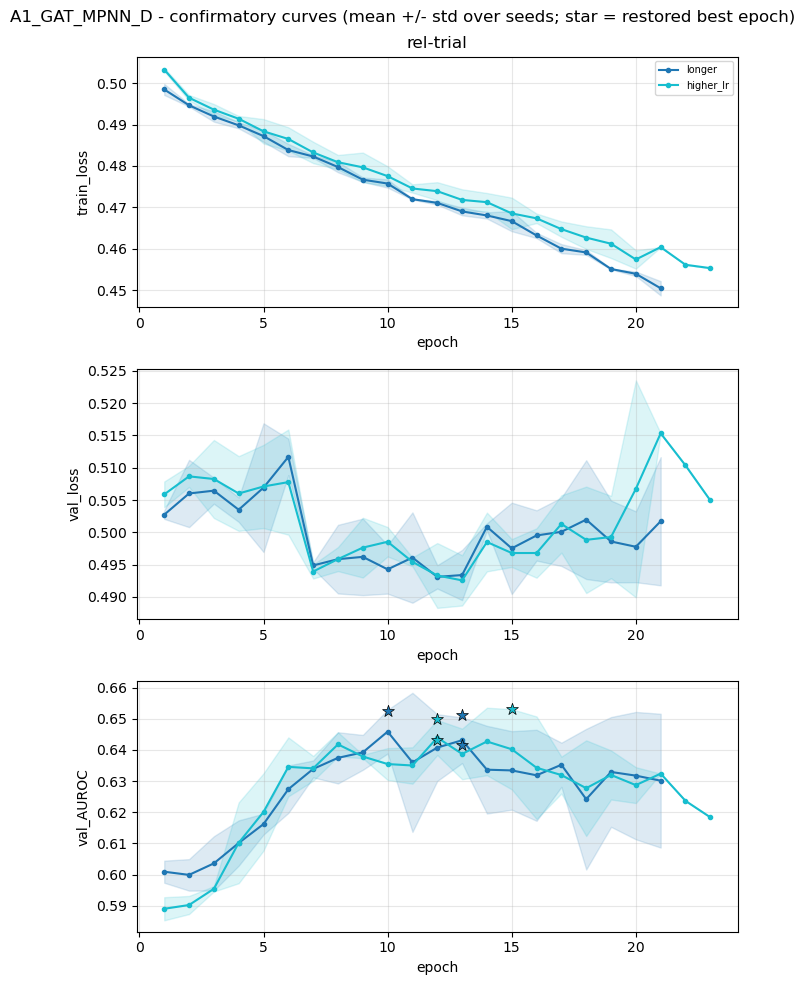

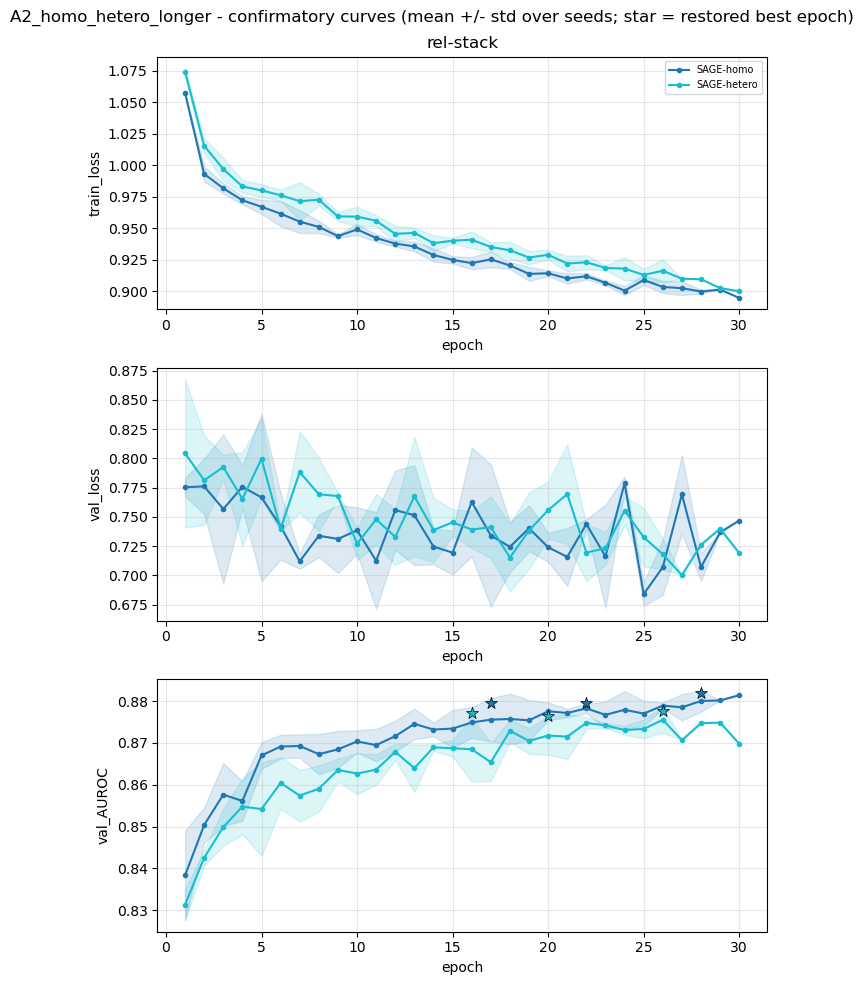

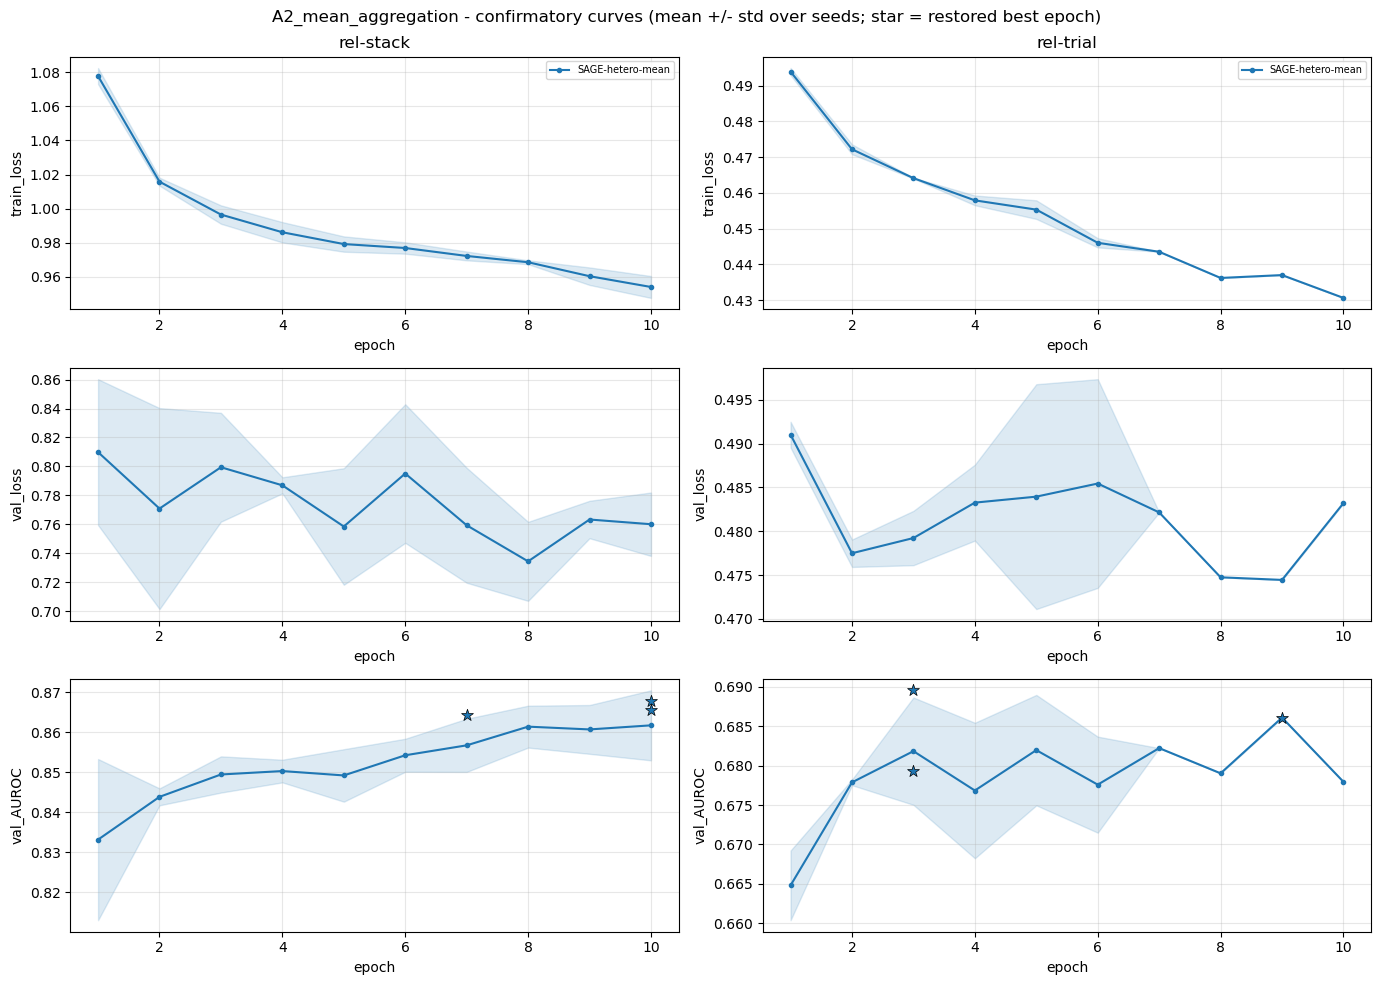

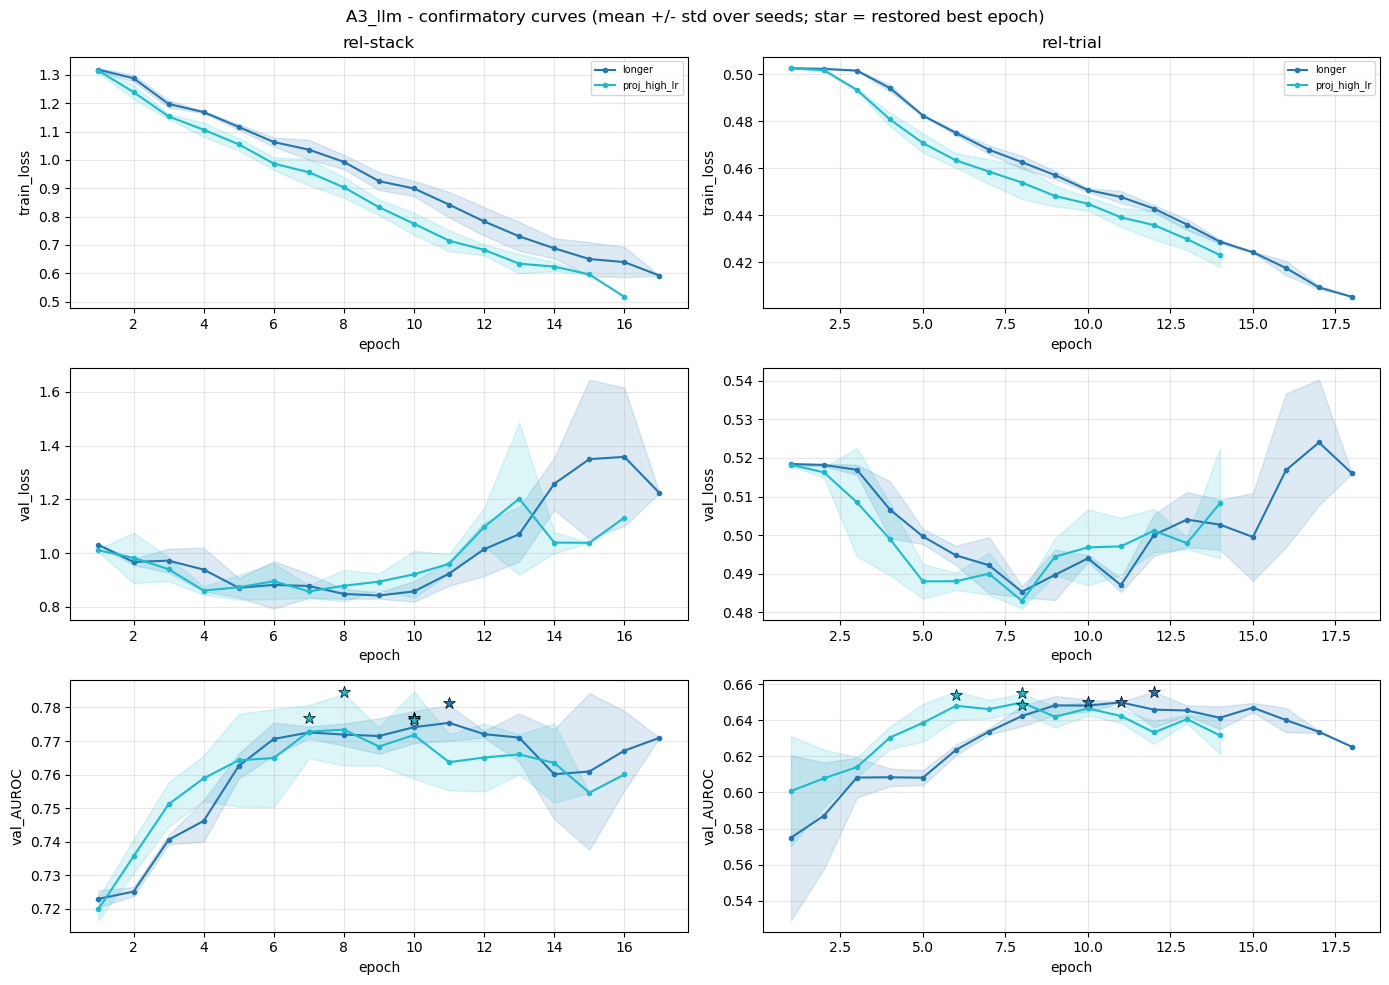

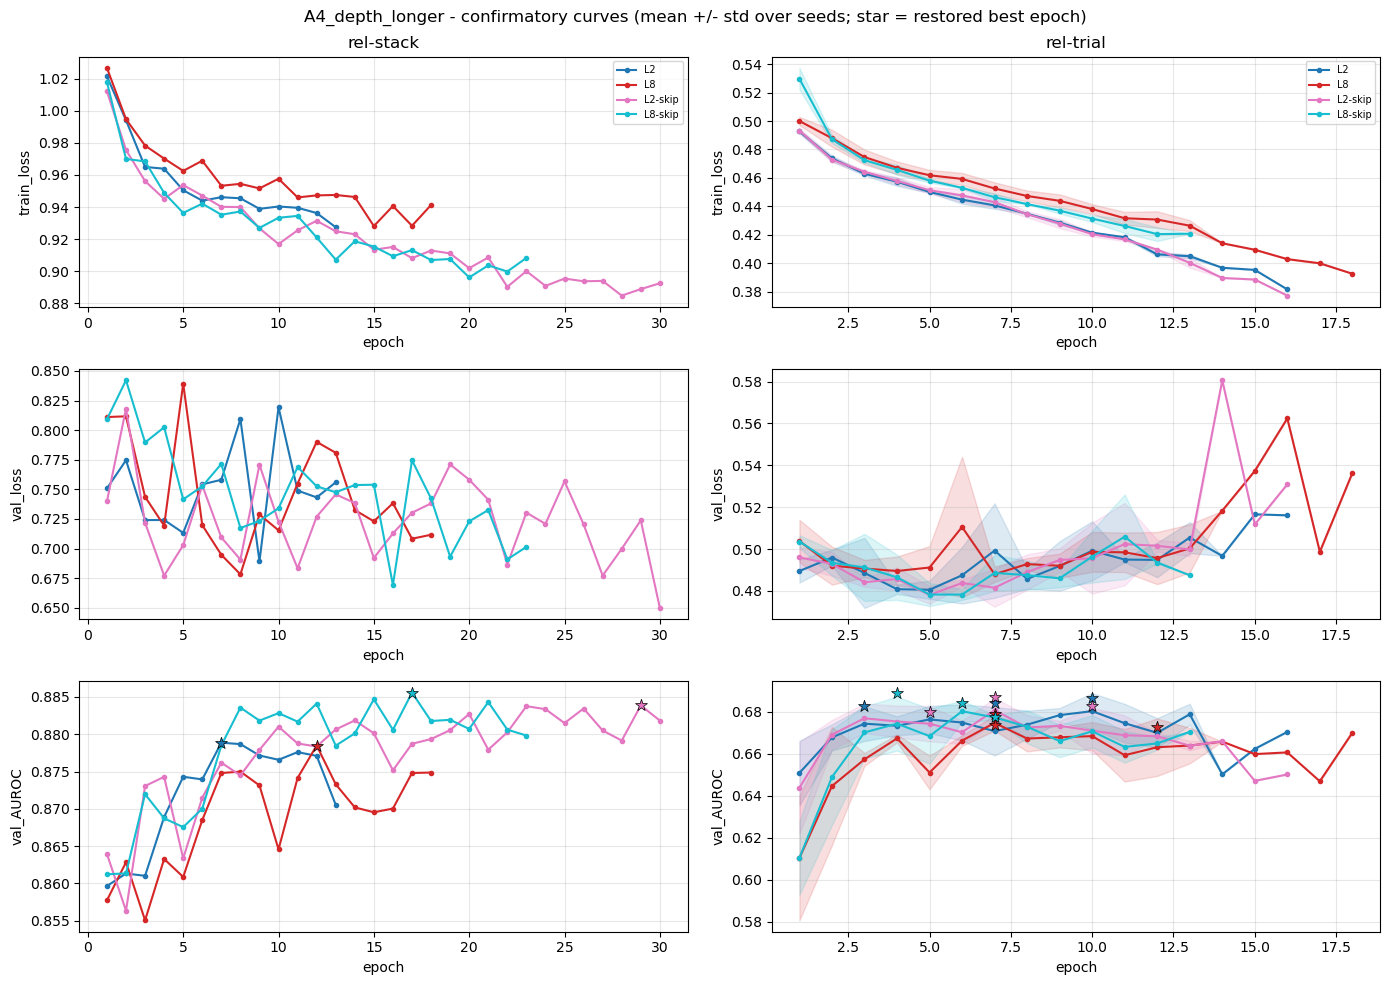

In [23]:
# ---------- Confirm figure: loss curves per confirmatory check ----------
_p = os.path.join(ARTIFACTS, "confirm_loss_curves.csv")
if not os.path.exists(_p):
    print("no confirm_loss_curves.csv yet - run the check cells first")
else:
    clc = pd.read_csv(_p)
    clc = clc[clc["done"] == True]     # full trajectories of finished runs only
    fin = clc[["check", "dataset", "variant", "seed"]].drop_duplicates()
    clc = pd.read_csv(_p).merge(fin, on=["check", "dataset", "variant", "seed"], how="inner")
    for check in clc["check"].unique():
        sub = clc[clc["check"] == check]
        dss = list(dict.fromkeys(sub.dataset))
        fig, axes = plt.subplots(3, len(dss), figsize=(7 * len(dss), 10), squeeze=False)
        for c, ds in enumerate(dss):
            d = sub[sub.dataset == ds]
            variants = list(dict.fromkeys(d.variant))
            cmap = plt.cm.tab10(np.linspace(0, 1, max(len(variants), 2)))
            for r, col in enumerate(["train_loss", "val_loss", "val_AUROC"]):
                ax = axes[r][c]
                for i, v in enumerate(variants):
                    dv = d[d.variant == v]
                    g = dv.groupby("epoch")[col]
                    mean, std, n = g.mean(), g.std().fillna(0.0), g.count()
                    ax.plot(mean.index, mean.values, marker=".", color=cmap[i], label=v)
                    if (n > 1).any():
                        ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                                        color=cmap[i], alpha=0.15)
                    if col == "val_AUROC":
                        stops = dv.loc[dv.groupby("seed")["val_AUROC"].idxmax()]
                        ax.scatter(stops["epoch"], stops["val_AUROC"], color=cmap[i], marker="*",
                                   s=80, zorder=5, edgecolor="black", linewidth=0.5)
                ax.set_xlabel("epoch"); ax.set_ylabel(col); ax.grid(alpha=0.3)
                if r == 0: ax.set_title(ds)
            axes[0][c].legend(fontsize=7)
        fig.suptitle(f"{check} - confirmatory curves (mean +/- std over seeds; star = restored best epoch)")
        fig.tight_layout()
        fig.savefig(os.path.join(ARTIFACTS, f"confirm_loss_{check}.png"), dpi=120, bbox_inches="tight")
        plt.show()


## Supplementary: SAGE Basis Decomposition (motivated by the edge-count imbalance in Aspect 2)

The edge-count listing showed rel-stack's 11 relations are wildly imbalanced (`votes.UserId->users` has 5,182 edges vs. `votes.PostId->posts`'s 1,199,831 - a 232x gap), while rel-trial's 15 relations are comparatively balanced (10x top-to-bottom, no severe outlier). The hypothesis: heterogeneous message passing doesn't fail because there are "too many" relations in absolute terms - it fails specifically where a relation's own independent weight matrix has to be estimated from too few examples. Basis decomposition (Schlichtkrull et al., the original R-GCN paper) is the standard fix: instead of every relation getting a fully independent weight matrix, each relation's matrix is a learned combination of a small shared set of `B` basis matrices. A thin-data relation no longer estimates an entire matrix alone - it only learns its combination coefficients, while the shared bases themselves get gradient signal from every relation, including the well-populated ones.

**Built on GraphSAGE, not RGCN.** The assignment's Aspect 2 model list is GraphSAGE/GAT/HGT (RGCN is only listed under Aspect 1's models), and PyG's native basis decomposition only ships on `RGCNConv`. So this is a hand-built `BasisSAGEConv` that reproduces `SAGEConv`'s exact formula - `out = lin_l(mean_neighbors) + lin_r(self)`, no bias on the self term, confirmed directly against PyG's own `SAGEConv` source before writing this - but constructs each relation's `lin_l`/`lin_r` weight matrices as `W = sum_b coef[rel,b] * basis[b]` instead of each relation owning fully independent, freely-learned matrices. The SAGE computation itself is unchanged; only where the weight matrices come from changes. Relations targeting the same destination node type are summed together, exactly matching the official hetero model's `HeteroConv(..., aggr="sum")` wrapping one independent `SAGEConv` per relation - so `num_bases = num_relations` is designed as the "no sharing" reference point within this same family (each relation *can* still learn an effectively independent matrix, just re-expressed through a large-enough basis, rather than a smaller architecture that can't represent independence at all).

**Implementation, verified before trusting it:**
- Confirmed `SAGEConv`'s exact forward computation from PyG's own source (`lin_l` on mean-aggregated neighbors with bias, `lin_r` on self features with no bias) before reproducing it.
- Confirmed `torch_geometric.utils.scatter(..., reduce="mean")` returns zero (not NaN) for destination nodes with zero contributing edges - needed since per-relation mean-aggregation routinely hits nodes with no neighbors of that specific relation in a given mini-batch.
- Relation IDs are fixed once, from the full graph's `data.edge_types` (same defensive practice as the earlier RGCN attempt, before it was replaced by this SAGE-native version) - the per-relation self-transform is applied to every destination node of that relation's type regardless of whether any edges of that relation appear in a given batch, matching `SAGEConv`'s own unconditional `lin_r(self)` behavior.
- Smoke-tested end-to-end on real sampled batches before committing to the full sweep: ran forward/backward on 13 real mini-batches at `num_bases=4`, confirmed every parameter's gradient was present and finite and no NaNs appeared in any output; separately confirmed `num_bases=num_relations` produces correctly-shaped output per node type.

**Basis-count sweep:** `{1, 2, 4, 8, num_relations}` per dataset (22 for rel-stack, 30 for rel-trial) - log-spaced rather than linear, so the sweep can distinguish "performance rises monotonically with more bases" (sharing never helps) from "performance peaks at a moderate basis count and comes back down toward the full-independence result" (moderate sharing is genuinely better than either extreme).

Reuses the project's existing, already-tested `train_model()`/`evaluate()` directly rather than a new training loop, and the same 30-epoch/patience-6/3-seed protocol as every other aspect, with the same per-epoch loss-curve logging so convergence gets checked the same way as everywhere else in this report. Output: `artifacts/aspect2_sage_basis_results.csv` and `artifacts/aspect2_sage_basis_loss_curves.csv`.

In [ ]:
# ---------- Supplementary: SAGE basis-decomposition sweep (motivated by Aspect 2) ----------
from torch_geometric.utils import scatter

class BasisSAGEConv(nn.Module):
    # Reproduces SAGEConv's exact formula (out = lin_l(mean_neighbors) + lin_r(self), no
    # bias on the self term - confirmed against PyG's own SAGEConv source), but each
    # relation's lin_l/lin_r weight matrices are built from a small shared set of B basis
    # matrices (W = sum_b coef[rel,b] * basis[b]) instead of being independently, freely
    # learned per relation. Relations targeting the same destination type are summed,
    # exactly matching HeteroConv(..., aggr="sum") wrapping one SAGEConv per relation.
    def __init__(self, ch, rel_names, num_bases, bias=True):
        super().__init__()
        R = len(rel_names); B = min(num_bases, R)
        self.ch = ch
        self.rel_id_of = {name: i for i, name in enumerate(rel_names)}
        self.basis_l = nn.Parameter(torch.empty(B, ch, ch))
        self.basis_r = nn.Parameter(torch.empty(B, ch, ch))
        self.coef_l = nn.Parameter(torch.empty(R, B))
        self.coef_r = nn.Parameter(torch.empty(R, B))
        self.bias_l = nn.Parameter(torch.zeros(R, ch)) if bias else None
        nn.init.xavier_uniform_(self.basis_l.view(B, -1))
        nn.init.xavier_uniform_(self.basis_r.view(B, -1))
        nn.init.xavier_uniform_(self.coef_l)
        nn.init.xavier_uniform_(self.coef_r)

    def forward(self, x_dict, edge_index_dict, node_types):
        out = {nt: torch.zeros(x_dict[nt].size(0), self.ch, device=x_dict[nt].device) for nt in node_types}
        for (s, rel, d), r in self.rel_id_of.items():
            ei = edge_index_dict.get((s, rel, d), None)
            W_l = torch.einsum("b,bij->ij", self.coef_l[r], self.basis_l)
            W_r = torch.einsum("b,bij->ij", self.coef_r[r], self.basis_r)
            n_dst = x_dict[d].size(0)
            if ei is not None and ei.numel() > 0:
                src, dst = ei
                agg = scatter(x_dict[s][src], dst, dim=0, dim_size=n_dst, reduce="mean")
            else:
                agg = torch.zeros(n_dst, x_dict[s].size(1), device=x_dict[d].device)
            msg = agg @ W_l.T
            if self.bias_l is not None:
                msg = msg + self.bias_l[r]
            msg = msg + x_dict[d] @ W_r.T
            out[d] = out[d] + msg
        return out

class SAGEBasisModel(nn.Module):
    # Same HeteroEncoder + head as the official Aspect 2 hetero SAGE model; only the
    # per-relation conv is replaced by BasisSAGEConv. rel_names is fixed once from the
    # full graph's edge types, never re-derived per batch.
    def __init__(self, data, col_stats, ch, L, num_bases, rel_names):
        super().__init__()
        self.encoder = HeteroEncoder(
            ch, {nt: data[nt].tf.col_names_dict for nt in data.node_types}, col_stats)
        self.node_types = list(data.node_types)
        self.convs = nn.ModuleList(
            [BasisSAGEConv(ch, rel_names, num_bases) for _ in range(L)])
        self.head = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, 1))

    def forward(self, batch, entity_table):
        x = self.encoder(batch.tf_dict)
        for conv in self.convs:
            o = conv(x, batch.edge_index_dict, self.node_types)
            x = {nt: torch.relu(o[nt]) for nt in x}
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(x[entity_table][:n]).squeeze(-1)

def run_sage_basis(dataset_name, task_name, num_bases_list, seeds=(42, 43, 44)):
    res_path = os.path.join(ARTIFACTS, "aspect2_sage_basis_results.csv")
    lc_path = os.path.join(ARTIFACTS, "aspect2_sage_basis_loss_curves.csv")
    res_rows = pd.read_csv(res_path).to_dict("records") if os.path.exists(res_path) else []
    done = {(r["dataset"], int(r["num_bases"]), int(r["seed"])) for r in res_rows}
    lc_start = lc_logger(lc_path)

    data, col_stats = build_or_load_graph(dataset_name)
    task = get_task(dataset_name, task_name, download=True); et = task.entity_table
    train_loader = make_loader(data, task, "train", shuffle=True)
    val_loader = make_loader(data, task, "val", shuffle=False)
    pw = pos_weight_of(task)
    rel_names = list(data.edge_types)   # fixed once, from the full graph - never per-batch
    print(f"{dataset_name}: {len(rel_names)} relations | basis sweep: {num_bases_list}")

    for num_bases in num_bases_list:
        for seed in seeds:
            if (dataset_name, num_bases, seed) in done:
                print(f"  bases={num_bases} seed={seed}: cached, skipping"); continue
            set_seed(seed)
            model = SAGEBasisModel(data, col_stats, HIDDEN, NUM_LAYERS, num_bases, rel_names).to(device)
            n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            cb = lc_start(dataset_name, f"sage-basis{num_bases}", seed)
            t0 = time.time()
            model = train_model(model, train_loader, val_loader, et, pw, on_epoch=cb)
            train_s = time.time() - t0
            m = evaluate(model, val_loader, et)
            m.update(dataset=dataset_name, num_bases=num_bases, seed=seed,
                     params=n_params, train_s=train_s)
            res_rows.append(m)
            pd.DataFrame(res_rows).to_csv(res_path, index=False)
            print(f"  bases={num_bases} seed={seed}: AUROC {m['AUROC']:.4f} | "
                  f"params {n_params:,} | {train_s:.0f}s", flush=True)
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()

    del data, col_stats, train_loader, val_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

In [ ]:
# ---------- Supplementary: run the SAGE basis-decomposition sweep ----------
# On the HPC this cell runs once per job for the dataset in SAGE_BASIS_DATASET (see
# hpc_sage_basis.py); locally (no env var set) it just loops over both datasets.
# Denser near the top end (12/16/20/...) than the original {1,2,4,8,N} sweep - the gap
# between 8 and N (22 or 30) was where the actual full-vs-shared transition happens, and
# it was originally the least-resolved part of the curve. run_sage_basis() is resumable
# (skips any (dataset, num_bases, seed) already in the results CSV), so widening this list
# does not recompute the points already collected under the original sweep.
_sb_targets = [t for t in TASKS if t[0] == os.environ["SAGE_BASIS_DATASET"]] \
    if os.environ.get("SAGE_BASIS_DATASET") else TASKS
_sb_sweeps = {
    "rel-stack": [1, 2, 4, 8, 12, 16, 20, 22],
    "rel-trial": [1, 2, 4, 8, 12, 16, 20, 24, 28, 30],
}
for name, tname in _sb_targets:
    print(f"\n##### sage-basis sweep: {name} #####")
    run_sage_basis(name, tname, num_bases_list=_sb_sweeps[name])

## Supplementary: Partial LLM Fine-Tuning + More Data (follow-up to `llm-finetuned`)

Full fine-tuning of MiniLM (all 6 layers, ~22.7M trainable params) came out *worse* than the frozen `llm` strategy on rel-trial (0.6388 vs 0.6545) despite being better on rel-stack. The likely cause: the shared A3 subsample is only 6,000 training seeds, and with `MAX_STEPS_PER_EPOCH` never binding at that scale (6,000 seeds / batch size 512 ≈ 12 batches per epoch, far under the 500-step cap), a 30-epoch budget means the model sees the *same* ~12 batches up to 30 times over - exactly the setup where a 22.7M-parameter model overfits a small, repeatedly-seen sample.

This follow-up tests two changes at once, motivated directly by that diagnosis:

1. **Partial fine-tuning**: freeze all of MiniLM except the last 1 or 2 transformer layers (embeddings and earlier layers stay frozen - only the top, most task-specific layers adapt). Verified directly before trusting it: ran a real forward/backward pass and confirmed frozen parameters never receive a gradient and unfrozen ones always do, with zero leakage either direction. `k=1` leaves 1.77M trainable params (7.8% of MiniLM), `k=2` leaves 3.55M (15.6%) - both far below the full fine-tune's 22.7M.
2. **More data**: a dedicated, larger subsample (30,000 train / 10,000 val seeds, 5x the official shared A3 sample) built specifically for this follow-up and cached separately (`aspect3_subgraphs_large/`) - it does **not** touch or replace the official A3 subsample used by `id`/`column`/`llm`/`llm-finetuned`, since those need to stay on the identical fixed sample per the assignment's requirement. At this scale there are ~58 batches/epoch instead of ~12, so a 30-epoch budget covers substantially more unique data before repeating.

Same discriminative-LR scheme as the full fine-tune (unfrozen MiniLM layers at `2e-5`, everything else at the usual `1e-3`), same 30-epoch/patience-6/3-seed protocol, same per-epoch loss-curve logging. Two variants (`k=1`, `k=2`) x 2 datasets x 3 seeds = 12 runs. Output: `artifacts/aspect3_partial_finetune_results.csv` and `artifacts/aspect3_partial_finetune_loss_curves.csv`, kept separate from both `aspect3_results.csv` and `aspect3_finetune_results.csv`.

In [ ]:
# ---------- Supplementary: partial LLM fine-tuning on a larger sample ----------
from sentence_transformers import SentenceTransformer
from torch.utils.checkpoint import checkpoint

A3_FT_MAXLEN = 256   # matches all-MiniLM-L6-v2's own max_seq_length (truncation behavior
                      # matches the frozen `llm` strategy's .encode() call)
A3_FT_CHUNK = 128     # cap nodes run through MiniLM per forward call - a graph mini-batch
                      # can carry thousands of nodes across hops/node-types, and running
                      # all of them through a live BERT at once OOMs an 11GB GPU
A3_LARGE_NTRAIN, A3_LARGE_NVAL = 30000, 10000
A3_LARGE_SUBDIR = os.path.join(ARTIFACTS, "aspect3_subgraphs_large")
A3_PARTIAL_MINI_LR = 2e-5   # same discriminative LR as the full fine-tune

def a3_build_or_load_large(dataset_name, task_name):
    # Dedicated, larger, separately-cached subsample for this follow-up only - does NOT
    # touch artifacts/aspect3_subgraphs/ (the official shared sample used by id/column/
    # llm/llm-finetuned). Mirrors a3_build_or_load's stratified-sampling logic but skips
    # the frozen llm_emb precompute (not needed here) and stores tokenized text tensors
    # instead (needed for a live, gradient-carrying MiniLM forward pass).
    os.makedirs(A3_LARGE_SUBDIR, exist_ok=True)
    path = os.path.join(A3_LARGE_SUBDIR, f"{dataset_name}.pt")
    if os.path.exists(path):
        return torch.load(path, weights_only=False)
    set_seed(SEED)
    data, col_stats = build_or_load_graph(dataset_name)
    db = get_dataset(dataset_name, download=True).get_db()
    task = get_task(dataset_name, task_name, download=True)
    et = task.entity_table

    def stratified(split_name, n):
        t = get_node_train_table_input(table=task.get_table(split_name), task=task)
        tgt = t.target
        pos = (tgt == 1).nonzero(as_tuple=True)[0]
        neg = (tgt == 0).nonzero(as_tuple=True)[0]
        n = min(n, len(tgt))
        n_pos = min(len(pos), round(n * len(pos) / len(tgt)))
        idx = torch.cat([pos[torch.randperm(len(pos))[:n_pos]],
                         neg[torch.randperm(len(neg))[:min(len(neg), n - n_pos)]]])
        idx = idx[torch.randperm(len(idx))]
        return t.nodes[1][idx], t.time[idx], t.target[idx].float()

    tn, tt, ty = stratified("train", A3_LARGE_NTRAIN)
    vn, vt, vy = stratified("val", A3_LARGE_NVAL)
    nodes, times = torch.cat([tn, vn]), torch.cat([tt, vt])
    y = torch.cat([ty, vy])
    split = torch.cat([torch.ones(len(tn)), torch.zeros(len(vn))]).bool()
    print(f"  [{dataset_name}] LARGE train n={len(tn)} pos-rate={ty.mean():.4f} | "
          f"val n={len(vn)} pos-rate={vy.mean():.4f}", flush=True)
    loader = NeighborLoader(data, num_neighbors=A3_FANOUT, time_attr="time",
                            input_nodes=(et, nodes), input_time=times,
                            batch_size=len(nodes), shuffle=False, num_workers=0)
    sub = next(iter(loader))
    n_seed = len(nodes)
    ys = torch.full((int(sub[et].num_nodes),), float("nan"))
    ys[:n_seed] = y
    sub[et].y = ys
    tok = SentenceTransformer(A3_LLM, device="cpu").tokenizer
    for nt in sub.node_types:
        gid = sub[nt].n_id.cpu().numpy()
        if len(gid) == 0:
            sub[nt].llm_input_ids = torch.zeros(0, A3_FT_MAXLEN, dtype=torch.long)
            sub[nt].llm_token_type_ids = torch.zeros(0, A3_FT_MAXLEN, dtype=torch.long)
            sub[nt].llm_attention_mask = torch.zeros(0, A3_FT_MAXLEN, dtype=torch.long)
            continue
        df = db.table_dict[nt].df; cols = list(df.columns); rows = df.iloc[gid]
        strs = [", ".join(f"{c}={rows.iloc[i][c]}" for c in cols) for i in range(len(rows))]
        enc = tok(strs, padding="max_length", truncation=True, max_length=A3_FT_MAXLEN,
                  return_tensors="pt")
        sub[nt].llm_input_ids = enc["input_ids"]
        sub[nt].llm_token_type_ids = enc["token_type_ids"]
        sub[nt].llm_attention_mask = enc["attention_mask"]
        print(f"    tokenized {nt}: {len(gid)} rows", flush=True)
    for nt in sub.node_types:
        sub[nt].gid = sub[nt].n_id
        for attr in ["n_id", "input_id", "batch_size", "seed_time"]:
            if hasattr(sub[nt], attr):
                del sub[nt][attr]
    for est in sub.edge_types:
        if hasattr(sub[est], "e_id"):
            del sub[est]["e_id"]
    blob = {"sub": sub, "split": split, "n_seed": n_seed, "seed_time": times,
            "col_stats": col_stats, "entity_table": et}
    torch.save(blob, path)
    del data, db; gc.collect()
    return blob

def ensure_llm_emb(blob, dataset_name):
    # Backward-compatible cache upgrade: adds precomputed frozen MiniLM sentence
    # embeddings (llm_emb) to an already-cached LARGE A3 subgraph blob, reusing the
    # exact same node sample via the `gid` provenance field - lets the large-sample
    # blob (built for the live-fine-tuning follow-ups, which only cache tokenized
    # text) also support the frozen `llm` strategy on the identical sample. Mirrors
    # a3_build_or_load's own frozen-embedding precompute block. Runs once; saved
    # back to cache.
    sub = blob["sub"]
    if all(hasattr(sub[nt], "llm_emb") for nt in sub.node_types):
        return blob
    mini = SentenceTransformer(A3_LLM, device=str(device))
    llm_dim = mini.get_sentence_embedding_dimension()
    db = get_dataset(dataset_name, download=True).get_db()
    for nt in sub.node_types:
        gid = sub[nt].gid.cpu().numpy()
        if len(gid) == 0:
            sub[nt].llm_emb = torch.zeros(0, llm_dim)
            continue
        df = db.table_dict[nt].df; cols = list(df.columns); rows = df.iloc[gid]
        strs = [", ".join(f"{c}={rows.iloc[i][c]}" for c in cols) for i in range(len(rows))]
        emb = mini.encode(strs, convert_to_numpy=True, batch_size=512, show_progress_bar=False)
        sub[nt].llm_emb = torch.from_numpy(np.asarray(emb).reshape(len(gid), -1)).float()
        print(f"    embedded {nt}: {len(gid)} rows", flush=True)
    blob["llm_dim"] = llm_dim
    del mini
    path = os.path.join(A3_LARGE_SUBDIR, f"{dataset_name}.pt")
    torch.save(blob, path)
    return blob

def freeze_all_but_last_k(mini, k):
    # Verified directly (see markdown above): frozen params never receive a gradient,
    # unfrozen ones always do, with zero leakage either direction.
    for name, p in mini.named_parameters():
        p.requires_grad = False
    n_layers = mini[0].auto_model.config.num_hidden_layers
    for name, p in mini.named_parameters():
        for layer_idx in range(n_layers - k, n_layers):
            if f"encoder.layer.{layer_idx}." in name:
                p.requires_grad = True

class A3PartialFinetuneModel(nn.Module):
    # Same architecture as the frozen/official llm strategy, but only the last k MiniLM transformer layers are trainable.
    def __init__(self, sub, ch, L, num_unfrozen, heads=A3_HEADS, llm_name=A3_LLM):
        super().__init__()
        self.nts = list(sub.node_types)
        self.mini = SentenceTransformer(llm_name, device=str(device))
        freeze_all_but_last_k(self.mini, num_unfrozen)
        llm_dim = self.mini.get_sentence_embedding_dimension()
        self.proj = nn.ModuleDict({nt: nn.Linear(llm_dim, ch) for nt in self.nts})
        self.convs = nn.ModuleList([HGTConv(ch, ch, sub.metadata(), heads=heads) for _ in range(L)])
        self.head = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, 1))

    def embed(self, store):
        if store.num_nodes == 0:
            return torch.zeros(0, self.mini.get_sentence_embedding_dimension(), device=device)
        def run_chunk(input_ids, token_type_ids, attention_mask):
            feats = {"input_ids": input_ids, "token_type_ids": token_type_ids,
                     "attention_mask": attention_mask}
            return self.mini(feats)["sentence_embedding"]
        outs = []
        for i in range(0, store.num_nodes, A3_FT_CHUNK):
            outs.append(checkpoint(run_chunk, store.llm_input_ids[i:i + A3_FT_CHUNK],
                                    store.llm_token_type_ids[i:i + A3_FT_CHUNK],
                                    store.llm_attention_mask[i:i + A3_FT_CHUNK],
                                    use_reentrant=False))
        return torch.cat(outs, dim=0)

    def forward(self, batch, entity_table):
        x = {nt: self.proj[nt](self.embed(batch[nt])) for nt in self.nts}
        for conv in self.convs:
            o = conv(x, batch.edge_index_dict)
            x = {nt: (torch.relu(o[nt]) if o.get(nt) is not None else x[nt]) for nt in x}
        store = batch[entity_table]
        n = getattr(store, "batch_size", None) or store.y.shape[0]
        return self.head(x[entity_table][:n]).squeeze(-1)

def train_a3_partial(model, train_loader, val_loader, entity_table, pos_weight,
                     on_epoch=None, epochs=None, patience=None):
    epochs = EPOCHS if epochs is None else epochs
    patience = PATIENCE if patience is None else patience
    mini_params = [p for p in model.mini.parameters() if p.requires_grad]
    rest_params = [p for n, p in model.named_parameters() if not n.startswith("mini.")]
    opt = torch.optim.Adam([{"params": rest_params, "lr": LR},
                            {"params": mini_params, "lr": A3_PARTIAL_MINI_LR}])
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_auroc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        train_losses = []
        for i, batch in enumerate(train_loader):
            if MAX_STEPS_PER_EPOCH and i >= MAX_STEPS_PER_EPOCH:
                break
            batch = batch.to(device)
            opt.zero_grad()
            logit = model(batch, entity_table)
            loss = loss_fn(logit, batch[entity_table].y.float())
            loss.backward(); opt.step()
            if on_epoch is not None:
                train_losses.append(loss.item())
        m = evaluate(model, val_loader, entity_table, loss_fn=loss_fn if on_epoch is not None else None)
        if on_epoch is not None:
            on_epoch(dict(epoch=ep + 1, train_loss=float(np.mean(train_losses)),
                          val_loss=m["loss"], val_AUROC=m["AUROC"]))
        if m["AUROC"] > best_auroc:
            best_auroc = m["AUROC"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def run_a3_partial_finetune(dataset_name, task_name, num_unfrozen_list=(1, 2), seeds=(42, 43, 44)):
    res_path = os.path.join(ARTIFACTS, "aspect3_partial_finetune_results.csv")
    lc_path = os.path.join(ARTIFACTS, "aspect3_partial_finetune_loss_curves.csv")
    res_rows = pd.read_csv(res_path).to_dict("records") if os.path.exists(res_path) else []
    done = {(r["dataset"], int(r["num_unfrozen"]), int(r["seed"])) for r in res_rows}
    lc_start = lc_logger(lc_path)

    blob = a3_build_or_load_large(dataset_name, task_name)
    sub, et = blob["sub"], blob["entity_table"]
    train_loader, val_loader, test_loader = a3_loaders_split(blob)
    ytr = sub[et].y[:blob["n_seed"]][blob["split"]]
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum().item(), 1.0)], device=device)

    for num_unfrozen in num_unfrozen_list:
        for seed in seeds:
            if (dataset_name, num_unfrozen, seed) in done:
                print(f"  k={num_unfrozen} seed={seed}: cached, skipping"); continue
            set_seed(seed)
            model = A3PartialFinetuneModel(sub, HIDDEN, NUM_LAYERS, num_unfrozen).to(device)
            n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            cb = lc_start(dataset_name, f"llm-partial{num_unfrozen}", seed)
            t0 = time.time()
            # early stopping uses train'/val' (carved from the official train pool) only
            model = train_a3_partial(model, train_loader, val_loader, et, pw, on_epoch=cb)
            train_s = time.time() - t0
            # final reported metric: the untouched official val pool, evaluated once, here
            m = evaluate(model, test_loader, et)
            m.update(dataset=dataset_name, num_unfrozen=num_unfrozen, seed=seed,
                     params=n_params, train_s=train_s)
            res_rows.append(m)
            pd.DataFrame(res_rows).to_csv(res_path, index=False)
            print(f"  k={num_unfrozen} seed={seed}: AUROC {m['AUROC']:.4f} | "
                  f"params {n_params:,} | {train_s:.0f}s", flush=True)
            del model; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()

    del blob, sub, train_loader, val_loader, test_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

In [ ]:
# ---------- Supplementary: run the partial-finetune + more-data follow-up ----------
# On the HPC this cell runs once per job for the dataset in A3_PARTIAL_DATASET, optionally
# restricted to the num_unfrozen values in A3_PARTIAL_UNFROZEN (see hpc_partial_finetune.py -
# lets the two configs for one dataset be split across two HPC accounts too, since each
# (dataset, k) shard is ~21h alone vs ~42h for the full dataset); locally (no env vars set)
# it just loops over both datasets and both configs.
_pf_targets = [t for t in TASKS if t[0] == os.environ["A3_PARTIAL_DATASET"]] \
    if os.environ.get("A3_PARTIAL_DATASET") else TASKS
_pf_unfrozen = tuple(int(k) for k in os.environ["A3_PARTIAL_UNFROZEN"].split(",")) \
    if os.environ.get("A3_PARTIAL_UNFROZEN") else (1, 2)
for name, tname in _pf_targets:
    print(f"\n##### llm-partial-finetune (more data): {name} #####")
    run_a3_partial_finetune(name, tname, num_unfrozen_list=_pf_unfrozen)

## Supplementary: Frozen `llm` Baseline, Same Sample and Protocol as the Partial Fine-Tune

Three experiments make up the final fine-tuning-family follow-up, all on the identical
30,000/10,000-seed sample and the identical train'/val'/test protocol (`a3_loaders_split()`,
see the `a3-partial-0` markdown cell), so the only thing that changes between them is how
much of MiniLM is allowed to adapt:

- **frozen** (this cell): all of MiniLM stays frozen, only a linear projection trains -
  same architecture as the official `A3Model(..., strategy="llm", ...)`.
- **k=1 / k=2** (cell above): last 1 or 2 MiniLM transformer layers unfrozen.

This cell reuses `A3Model` and the shared `train_model()` harness unchanged, on the large
sample via `a3_build_or_load_large` plus `ensure_llm_emb` (a cache upgrade that adds the
precomputed frozen embeddings the large-sample blob doesn't otherwise need, since it was
originally built only for live fine-tuning). Output:
`artifacts/aspect3_llm_frozen_large_results.csv` and `..._loss_curves.csv`.

In [ ]:
# ---------- Supplementary: frozen llm baseline, large sample + train'/val'/test protocol ----------
def run_a3_llm_frozen_large(dataset_name, task_name, seeds=(42, 43, 44)):
    res_path = os.path.join(ARTIFACTS, "aspect3_llm_frozen_large_results.csv")
    lc_path = os.path.join(ARTIFACTS, "aspect3_llm_frozen_large_loss_curves.csv")
    res_rows = pd.read_csv(res_path).to_dict("records") if os.path.exists(res_path) else []
    done = {(r["dataset"], int(r["seed"])) for r in res_rows}
    lc_start = lc_logger(lc_path)

    blob = a3_build_or_load_large(dataset_name, task_name)
    blob = ensure_llm_emb(blob, dataset_name)
    sub, et = blob["sub"], blob["entity_table"]
    train_loader, val_loader, test_loader = a3_loaders_split(blob)
    ytr = sub[et].y[:blob["n_seed"]][blob["split"]]
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum().item(), 1.0)], device=device)

    for seed in seeds:
        if (dataset_name, seed) in done:
            print(f"  seed {seed}: cached, skipping"); continue
        set_seed(seed)
        model = A3Model(sub, blob["col_stats"], HIDDEN, NUM_LAYERS, "llm", blob["llm_dim"]).to(device)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        cb = lc_start(dataset_name, "llm-frozen-large", seed)
        t0 = time.time()
        # early stopping uses train'/val' (carved from the official train pool) only
        model = train_model(model, train_loader, val_loader, et, pw, on_epoch=cb)
        train_s = time.time() - t0
        # final reported metric: the untouched official val pool, evaluated once, here
        m = evaluate(model, test_loader, et)
        m.update(dataset=dataset_name, strategy="llm-frozen-large", seed=seed,
                 params=n_params, train_s=train_s)
        res_rows.append(m)
        pd.DataFrame(res_rows).to_csv(res_path, index=False)
        print(f"  seed {seed}: AUROC {m['AUROC']:.4f} | params {n_params:,} | {train_s:.0f}s", flush=True)
        del model; gc.collect()
        if device.type == "cuda": torch.cuda.empty_cache()

    del blob, sub, train_loader, val_loader, test_loader; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

In [ ]:
# ---------- Supplementary: run the frozen llm baseline (large sample) ----------
# On the HPC this cell runs once per job for the dataset in A3_LLMFROZEN_DATASET (see
# hpc_llm_frozen_large.py); locally (no env var set) it just loops over both datasets.
_lfl_targets = [t for t in TASKS if t[0] == os.environ["A3_LLMFROZEN_DATASET"]] \
    if os.environ.get("A3_LLMFROZEN_DATASET") else TASKS
for name, tname in _lfl_targets:
    print(f"\n##### llm-frozen (large sample): {name} #####")
    run_a3_llm_frozen_large(name, tname)